# Softmax regression with $l_1$

In [1]:
!pip install ucimlrepo

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad
from scipy.optimize import minimize_scalar
import jax.numpy as jnp
from jax import grad, jit, hessian
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
from ucimlrepo import fetch_ucirepo
from optax.losses import safe_softmax_cross_entropy as cros_entr
from itertools import product
# Define softmax function
@jit
def softmax(z):
    exp_z = jnp.exp(z - jnp.max(z, axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

# Define cross-entropy loss
@jit
def cross_entropy_loss_log(w, X, y):
    predictions = X @ w
    n = len(X)
    log_likelihoods = jax.scipy.special.logsumexp(predictions, axis=1)
    cross_entropy = log_likelihoods - jnp.sum(jnp.multiply(predictions, y), axis=1)
    return (1/n) * jnp.sum(cross_entropy)

@jit
def loss(w, X, y, lam):
  return cross_entropy_loss_log(w, X, y) + lam * jnp.sum(jnp.abs(w))

# Set a random seed for reproducibility
np.random.seed(228)
jax.random.PRNGKey(228)

def compute_optimal(X, y, lam):
    n, d = X.shape
    k = y.shape[1]  # Assuming y is one-hot encoded, number of classes

    # Define the variable for weights
    w = cp.Variable((d, k))

    # Construct the objective
    logits = X @ w
    log_likelihoods = cp.log_sum_exp(logits, axis=1)
    cross_entropy_loss = cp.sum(log_likelihoods) - cp.sum(cp.multiply(y, logits))

    # Add l1 regularization
    l1_reg = lam * cp.sum(cp.abs(w))

    # Total loss
    loss = (1/n) * cross_entropy_loss + l1_reg

    # Define the problem
    problem = cp.Problem(cp.Minimize(loss))

    # Solve the problem
    problem.solve()

    # Extract the optimal weights and minimum loss
    w_star = w.value
    f_star = problem.value

    return w_star, f_star

def generate_problem():
    # Fetch dataset from UCI repository
    dataset = fetch_ucirepo(id=697)

    # Extract features and targets
    X = dataset.data.features.values
    y = dataset.data.targets.values.flatten()

    # Create a mapping from unique labels to integers
    unique_labels = np.unique(y)
    num_classes = len(unique_labels)
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}

    # Convert labels to integers using the mapping
    y_integers = jnp.array([label_to_int[label] for label in y])

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y_integers, test_size=0.33, random_state=42)

    # Normalize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # One-hot encoding using jax
    y_train_one_hot = jax.nn.one_hot(y_train, num_classes)
    y_test_one_hot = jax.nn.one_hot(y_test, num_classes)

    return X_train, y_train_one_hot, X_test, y_test_one_hot

def subgradient_descent(w_0, X, y, f_star, lr_method="const", learning_rate=0.01, num_iters=100, lam=1, tol=0.1):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: cross_entropy_loss_log(w, X, y)
    f_full = lambda w: cross_entropy_loss_log(w, X, y) + lam * jnp.sum(jnp.abs(w))
    iter_start = time.time()
    n = X.shape[0]

    for i in range(num_iters):
        iter_time = time.time()
        logits = X @ w
        P = softmax(logits)
        diff = P - y
        grad_ce =  (X.T @ diff) / n
        subgrad_l1 = jnp.sign(w)
        if lr_method =="const":
          w = w - learning_rate * (grad_ce + lam * subgrad_l1)
        else:
          w = w - learning_rate(i) * (grad_ce + lam * subgrad_l1)
        # grad_fn = jit(grad(loss))
        # w -= learning_rate*grad_fn(w, X, y, lam)
        trajectory.append(w)
        times.append(iter_time - iter_start)
        if (jnp.abs(f_full(w) - f_star) <= tol):
          break
    return trajectory, times


def proximal_gradient_method(w_0, X, y, learning_rate=0.01, num_iters=100, lam=1):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: cross_entropy_loss_log(w, X, y)

    iter_start = time.time()
    for i in range(num_iters):
        ### YOUR CODE HERE ###
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    return trajectory, times

# Compute accuracy
def compute_accuracy(w, X, y):
    predictions = softmax(X @ w)
    predicted_classes = jnp.argmax(predictions, axis=1)
    true_classes = jnp.argmax(y, axis=1)
    accuracy = jnp.mean(predicted_classes == true_classes)
    return accuracy

# Compute metrics
def compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, lam):
    f = lambda w: cross_entropy_loss_log(w, X_train, y_train) + lam * jnp.sum(jnp.abs(w))
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "time": times,
        "train_acc": [compute_accuracy(x, X_train, y_train) for x in trajectory],
        "test_acc": [compute_accuracy(x, X_test, y_test) for x in trajectory],
        "sparsity": [jnp.mean(jnp.abs(x) < 1e-5) for x in trajectory]
    }
    return metrics

def run_experiments(params):
    lam = params["lam"]
    methods = params["methods"]
    results = {}
    tol = params["tolerance"]
    X_train, y_train, X_test, y_test = generate_problem()
    n_features = X_train.shape[1]
    n_classes = len(y_train[0])
    params["n_features"], params["n_classes"] = n_features, n_classes

    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n_features, n_classes))
    x_star, f_star = compute_optimal(X_train, y_train, lam)
    print(f"Optimal accuracy {compute_accuracy(x_star, X_train, y_train)}")

    for method in methods:
        if method["method"] == "Subgrad":
            f_full = lambda w: cross_entropy_loss_log(w, X_train, y_train) + lam * jnp.sum(jnp.abs(w))
            lr_method = method["lr_method"]
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = subgradient_descent(x_0, X_train, y_train, f_star, lr_method, learning_rate, iterations, lam, tol)
            w = trajectory[-1]

            train_acc = compute_accuracy(w, X_train, y_train)
            test_acc = compute_accuracy(w, X_test, y_test)
            print(f"Last diff: {jnp.abs(f_full(w) - f_star)},iter: {len(trajectory)-1}")
            print(f"train accuracy: {train_acc}, test_accuracy: {test_acc}")
            if method["lr_method"] == "const":
              label = method["method"] + f" lr {learning_rate:.2f}"
            else:
              label = method["method"] + f" lr 1/sqrt(1+i)"
            metrics = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, lam)
            results[label] = metrics
        elif method["method"] == "Proximal":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = proximal_gradient_method(x_0, X_train, y_train, f_star, learning_rate, iterations, lam, tol)
            if method["lr_method"]=="const":
              label = method["method"] + f" lr {learning_rate:.2f}"
            else:
              label = method["method"] + f" lr 1/sqrt(1+i)"
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, lam)

    return results, params

def plot_results(results, params):
    plt.figure(figsize=(11, 5))
    lam = params["lam"]

    plt.suptitle(f"Convex multiclass regression. lam={lam}.")

    plt.subplot(2, 4, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'], label=method + f" sparsity {metrics['sparsity'][-1]:.3f}")
    plt.xlabel('Iteration')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 3)
    for method, metrics in results.items():
        plt.plot(metrics["train_acc"])
    plt.xlabel('Iteration')
    plt.ylabel('Train accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 4)
    for method, metrics in results.items():
        plt.plot(metrics["test_acc"])
    plt.xlabel('Iteration')
    plt.ylabel('Test accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 5)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics['f_gap'])
    plt.xlabel('Time')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 6)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics['x_gap'])
    plt.xlabel('Time')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 7)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics["train_acc"])
    plt.xlabel('Time')
    plt.ylabel('Train accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 8)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics["test_acc"])
    plt.xlabel('Time')
    plt.ylabel('Test accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.00))
    # Adjust layout to make space for the legend below
    filename = ""
    for method, metrics in results.items():
        filename += method
    filename += f"_{lam}.pdf"
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename)
    plt.show()

<>:225: SyntaxWarning: invalid escape sequence '\|'
<>:257: SyntaxWarning: invalid escape sequence '\|'
<>:225: SyntaxWarning: invalid escape sequence '\|'
<>:257: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipython-input-2636156114.py:225: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|x_k - x^*\|$')
/tmp/ipython-input-2636156114.py:257: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|x_k - x^*\|$')


learning rate: 0.01, tolerance: 0.1
Optimal accuracy 0.7763157486915588
Last diff: 0.09999781847000122,iter: 6655
train accuracy: 0.7739540934562683, test_accuracy: 0.749315083026886


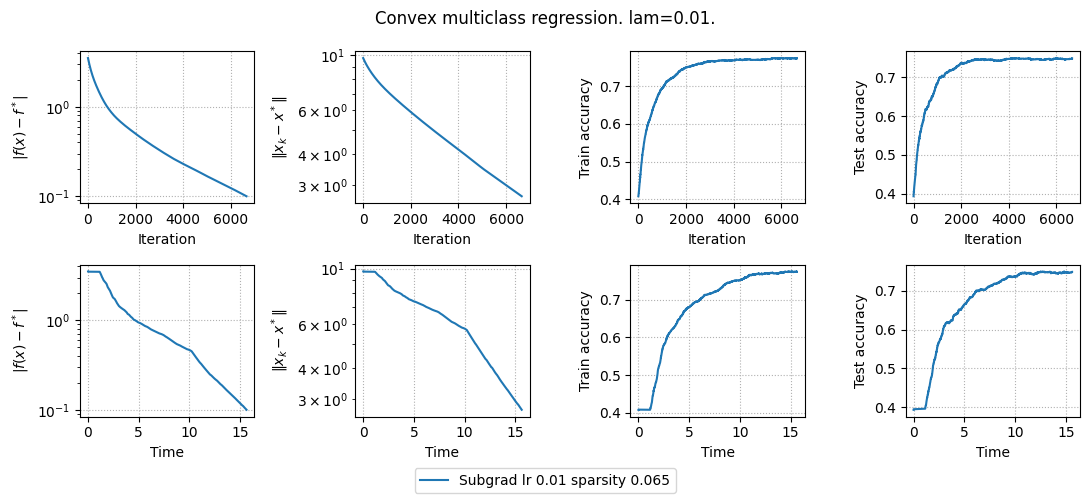

learning rate: 0.01, tolerance: 0.01
Optimal accuracy 0.7763157486915588
Last diff: 0.02857041358947754,iter: 10000
train accuracy: 0.7709176540374756, test_accuracy: 0.7541096210479736


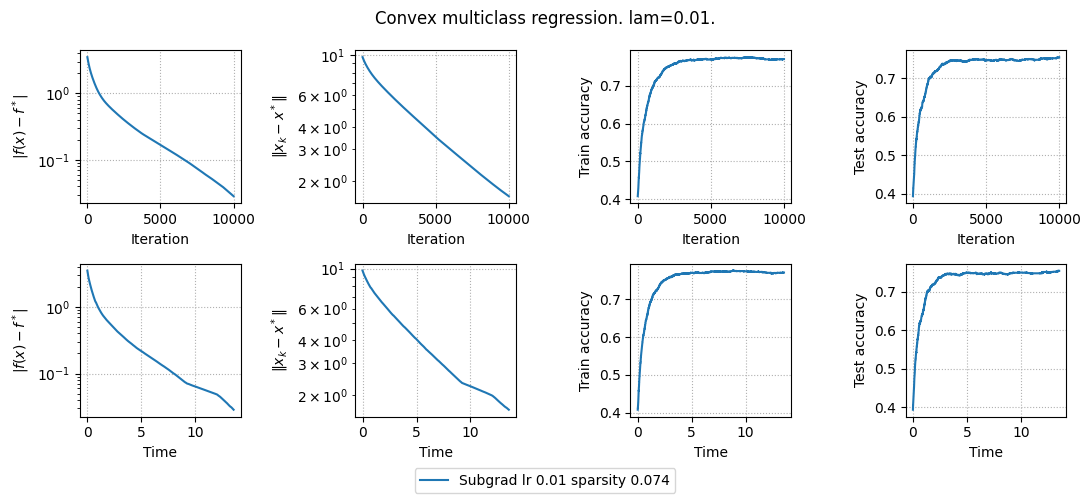

learning rate: 0.01, tolerance: 0.001
Optimal accuracy 0.7763157486915588
Last diff: 0.02857041358947754,iter: 10000
train accuracy: 0.7709176540374756, test_accuracy: 0.7541096210479736


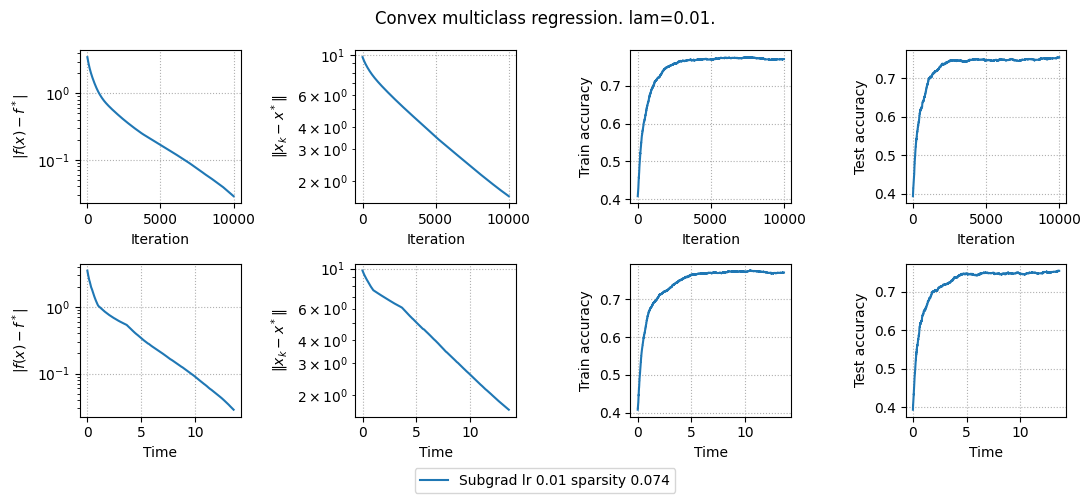

learning rate: 0.01, tolerance: 0.0001
Optimal accuracy 0.7763157486915588
Last diff: 0.02857041358947754,iter: 10000
train accuracy: 0.7709176540374756, test_accuracy: 0.7541096210479736


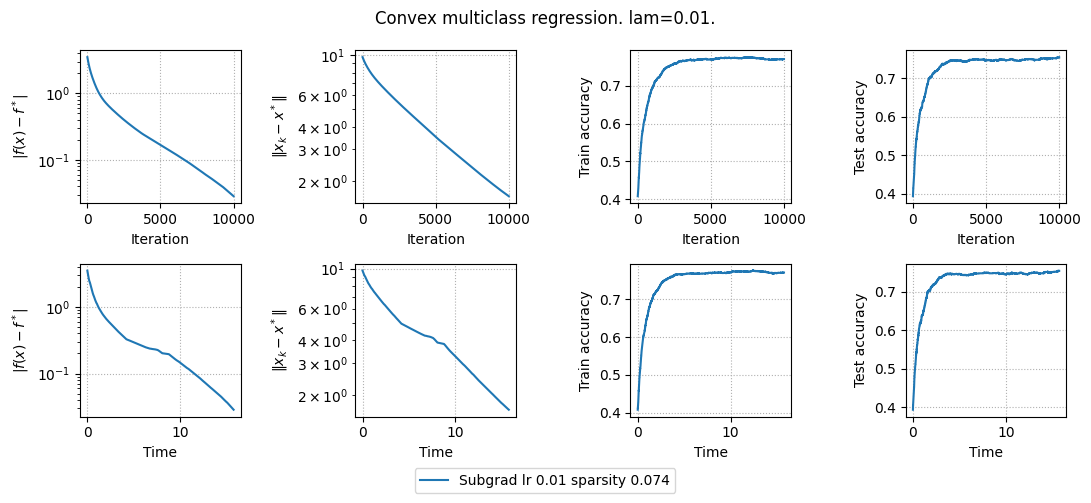

learning rate: 0.01, tolerance: 1e-05
Optimal accuracy 0.7763157486915588
Last diff: 0.02857041358947754,iter: 10000
train accuracy: 0.7709176540374756, test_accuracy: 0.7541096210479736


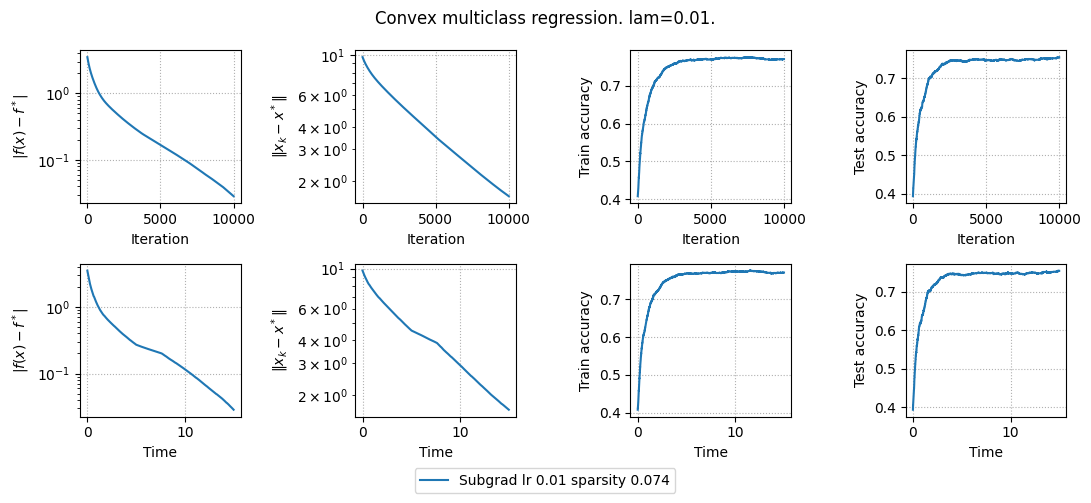

learning rate: 0.1, tolerance: 0.1
Optimal accuracy 0.7763157486915588
Last diff: 0.09972220659255981,iter: 667
train accuracy: 0.7739540934562683, test_accuracy: 0.749315083026886


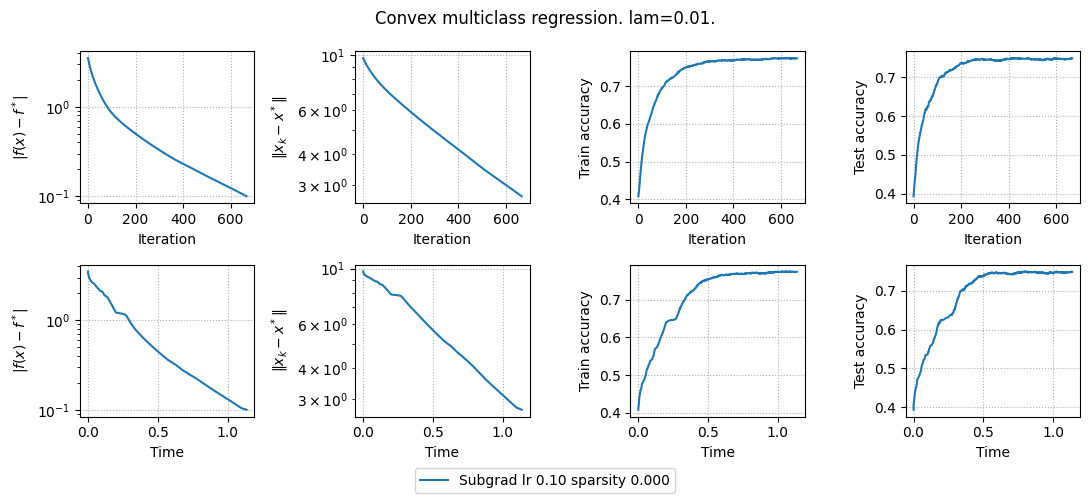

learning rate: 0.1, tolerance: 0.01
Optimal accuracy 0.7763157486915588
Last diff: 0.009986162185668945,iter: 1217
train accuracy: 0.7732793092727661, test_accuracy: 0.748630166053772


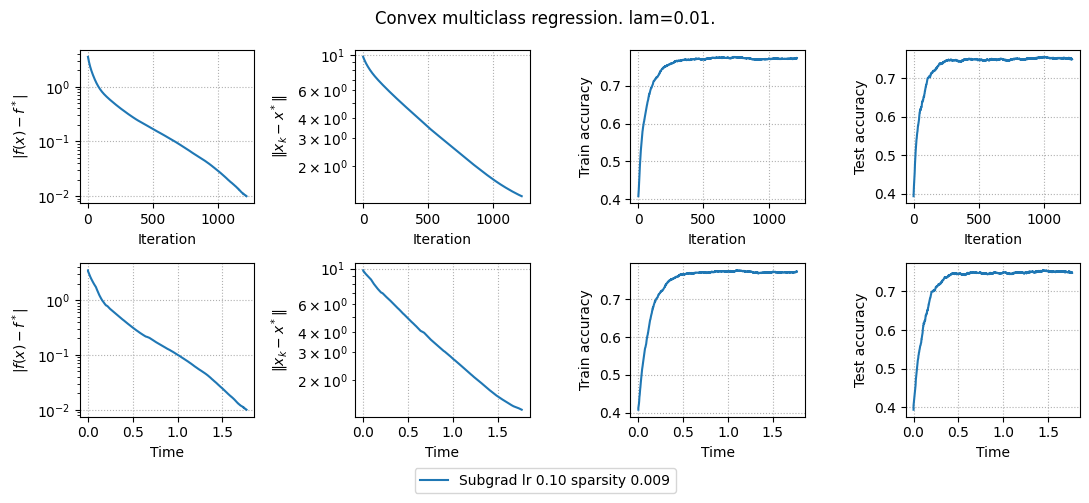

learning rate: 0.1, tolerance: 0.001
Optimal accuracy 0.7763157486915588
Last diff: 0.0009782910346984863,iter: 2584
train accuracy: 0.776990532875061, test_accuracy: 0.7513698935508728


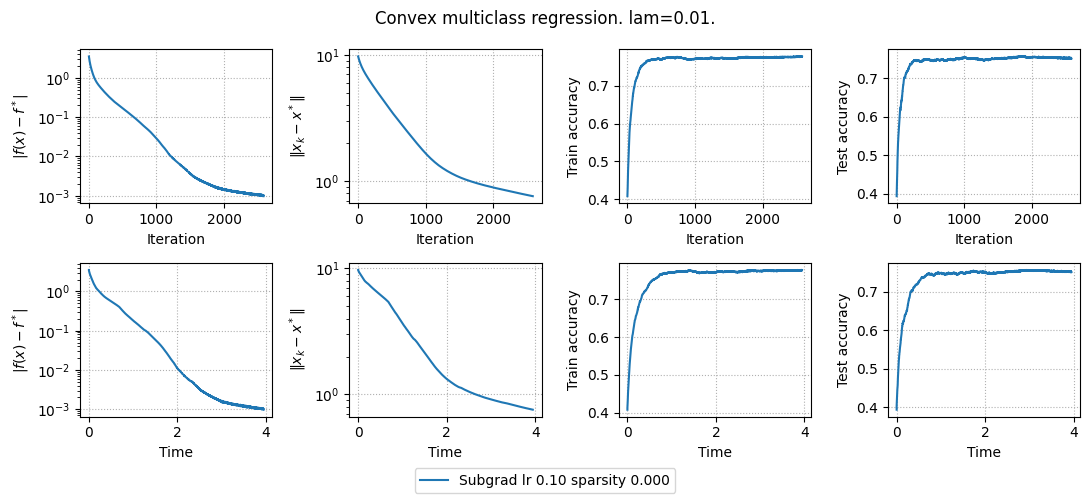

learning rate: 0.1, tolerance: 0.0001
Optimal accuracy 0.7763157486915588
Last diff: 0.00033020973205566406,iter: 10000
train accuracy: 0.7759783864021301, test_accuracy: 0.747945249080658


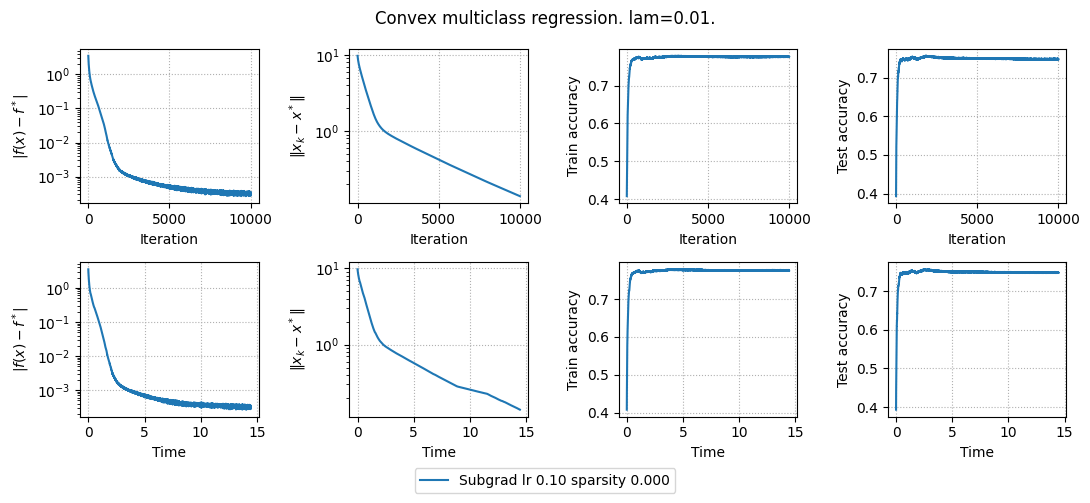

learning rate: 0.1, tolerance: 1e-05
Optimal accuracy 0.7763157486915588
Last diff: 0.00033020973205566406,iter: 10000
train accuracy: 0.7759783864021301, test_accuracy: 0.747945249080658


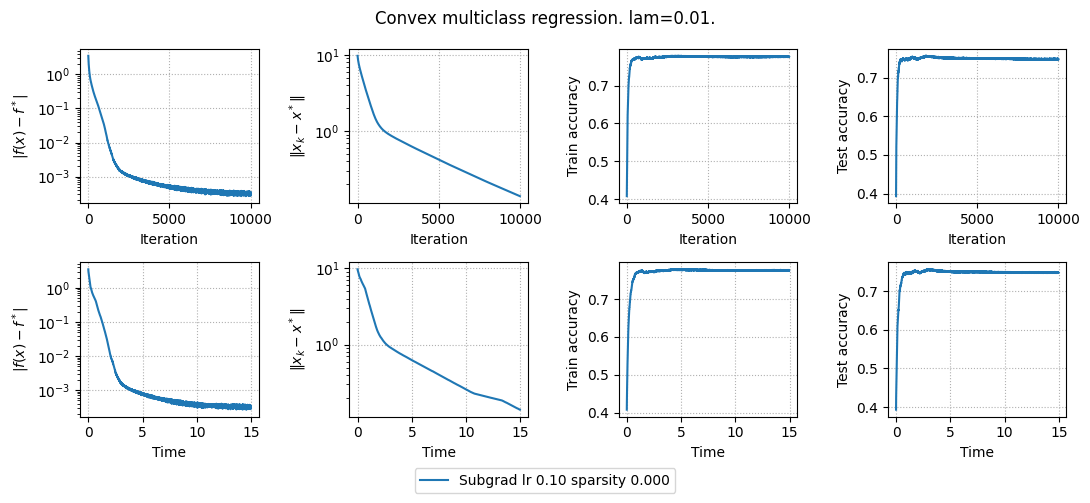

learning rate: 0.15, tolerance: 0.1
Optimal accuracy 0.7763157486915588
Last diff: 0.09965938329696655,iter: 445
train accuracy: 0.7739540934562683, test_accuracy: 0.749315083026886


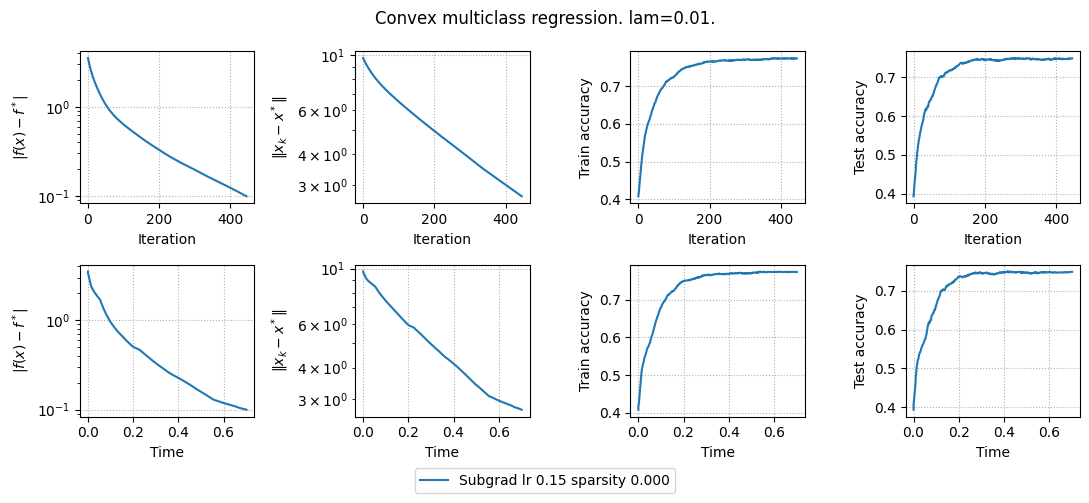

learning rate: 0.15, tolerance: 0.01
Optimal accuracy 0.7763157486915588
Last diff: 0.009993493556976318,iter: 814
train accuracy: 0.7722671627998352, test_accuracy: 0.7513698935508728


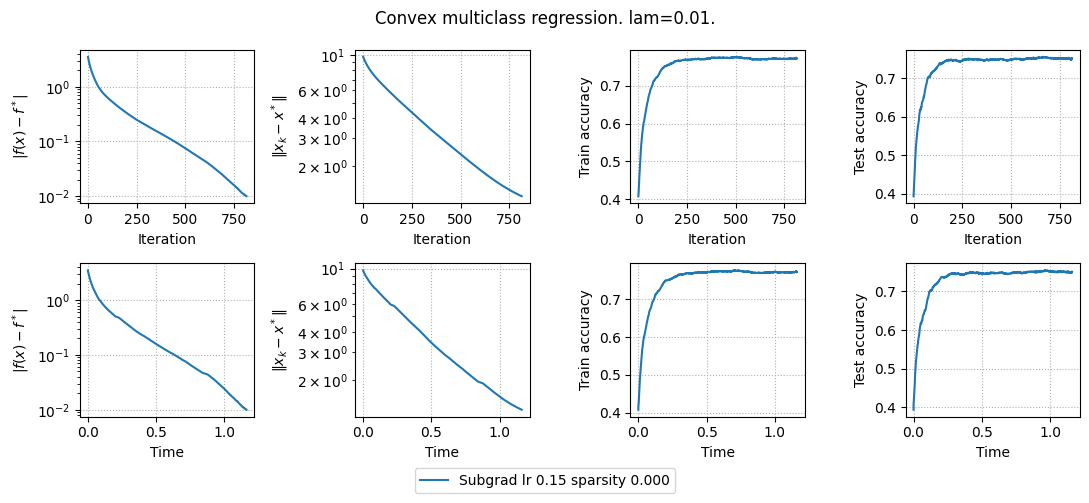

learning rate: 0.15, tolerance: 0.001
Optimal accuracy 0.7763157486915588
Last diff: 0.0009968280792236328,iter: 1959
train accuracy: 0.7773278951644897, test_accuracy: 0.7527397274971008


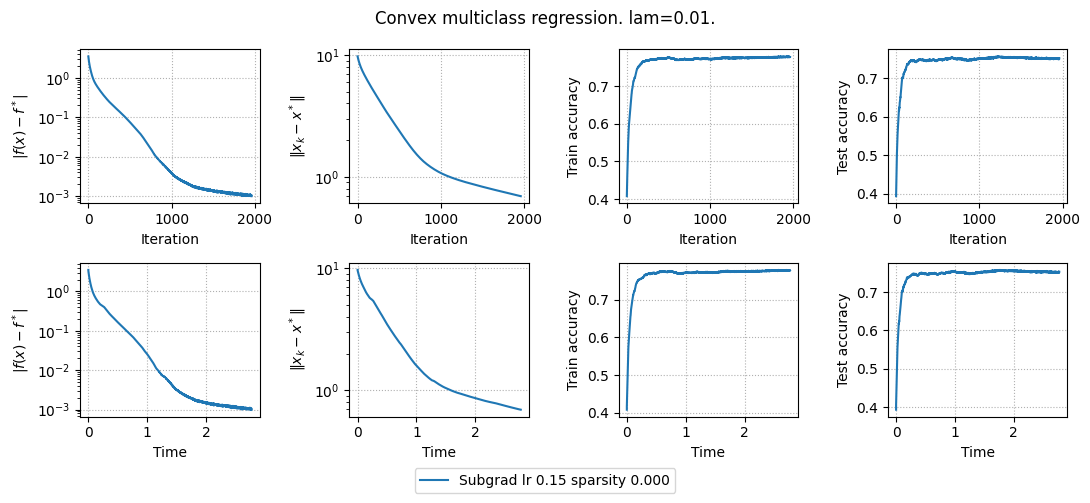

learning rate: 0.15, tolerance: 0.0001
Optimal accuracy 0.7763157486915588
Last diff: 0.000431060791015625,iter: 10000
train accuracy: 0.7756410241127014, test_accuracy: 0.7472602725028992


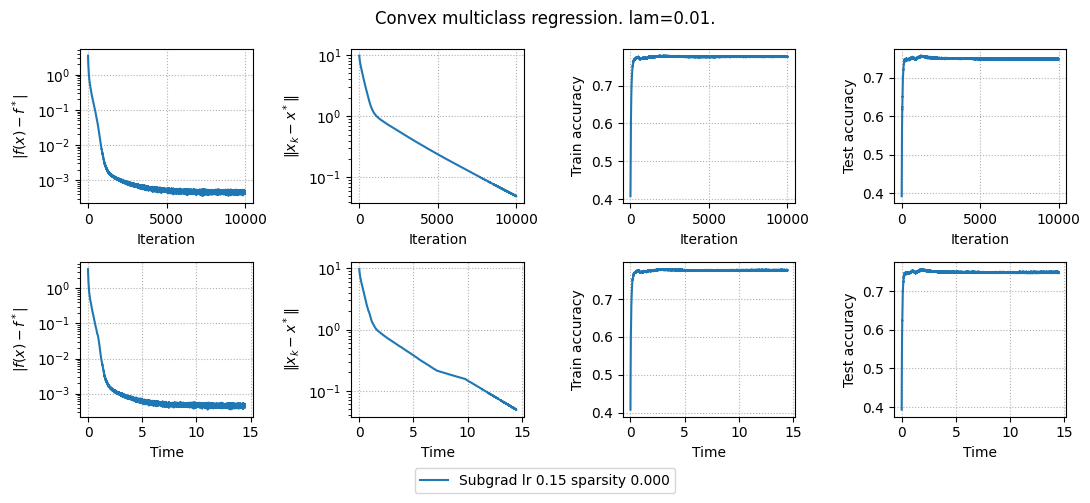

learning rate: 0.15, tolerance: 1e-05
Optimal accuracy 0.7763157486915588
Last diff: 0.000431060791015625,iter: 10000
train accuracy: 0.7756410241127014, test_accuracy: 0.7472602725028992


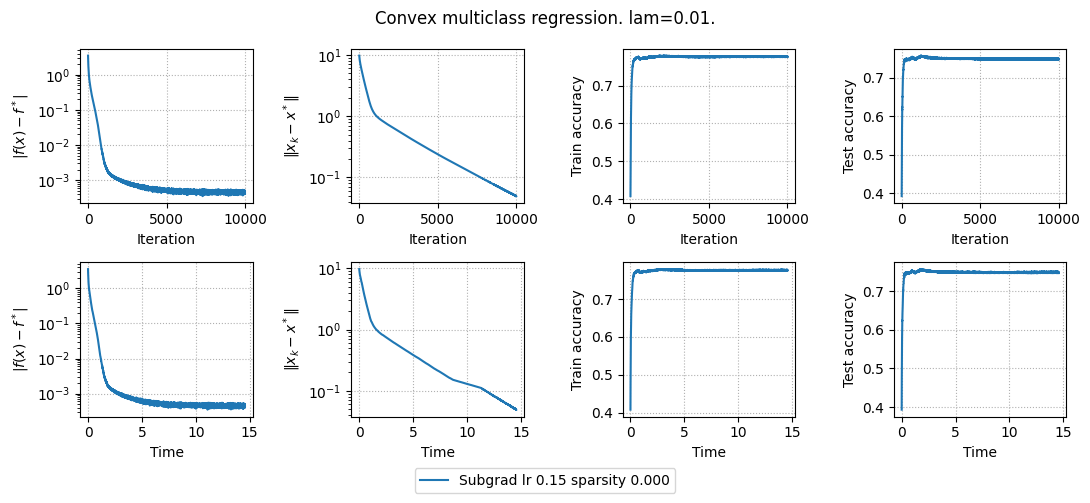

learning rate: 0.2, tolerance: 0.1
Optimal accuracy 0.7763157486915588
Last diff: 0.09958529472351074,iter: 334
train accuracy: 0.7739540934562683, test_accuracy: 0.748630166053772


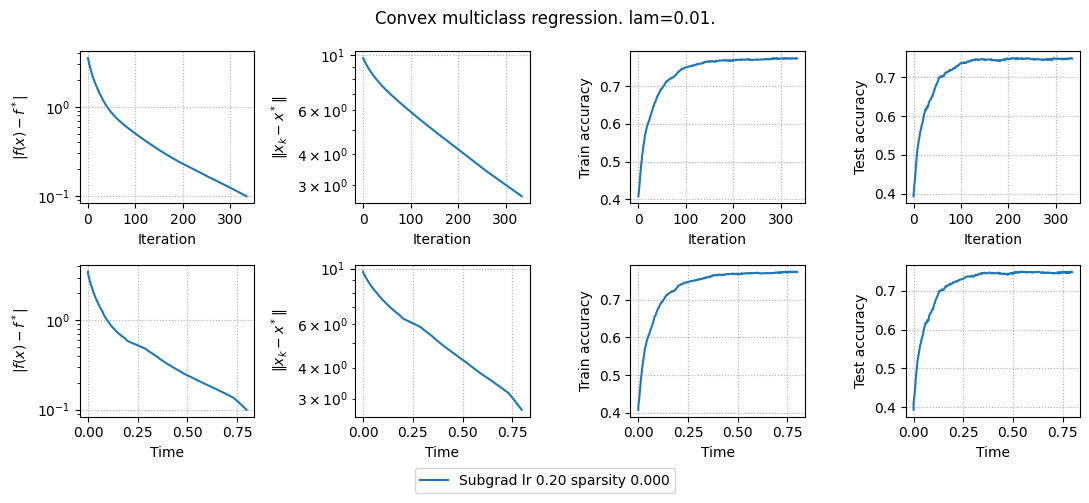

learning rate: 0.2, tolerance: 0.01
Optimal accuracy 0.7763157486915588
Last diff: 0.009987354278564453,iter: 612
train accuracy: 0.7722671627998352, test_accuracy: 0.747945249080658


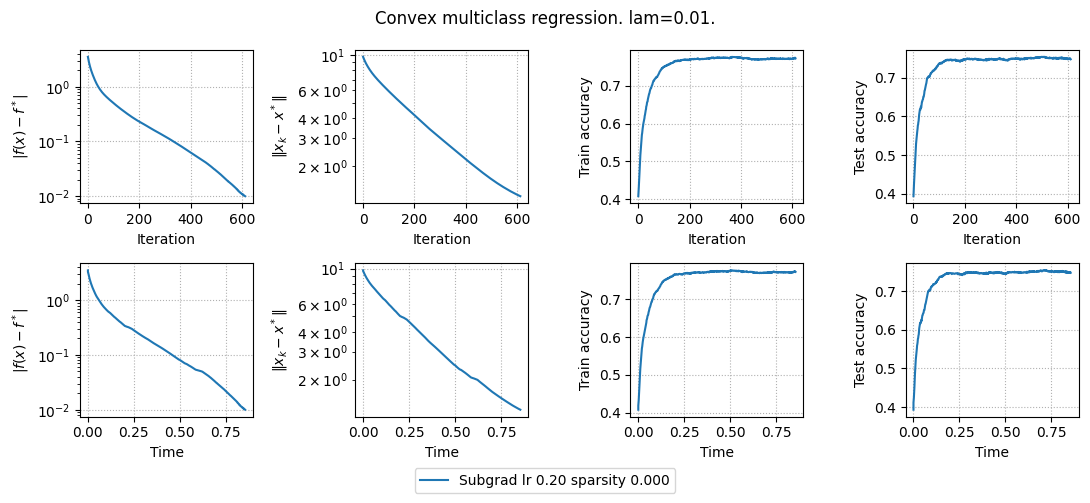

learning rate: 0.2, tolerance: 0.001
Optimal accuracy 0.7763157486915588
Last diff: 0.0009702444076538086,iter: 1639
train accuracy: 0.7780026793479919, test_accuracy: 0.7506849765777588


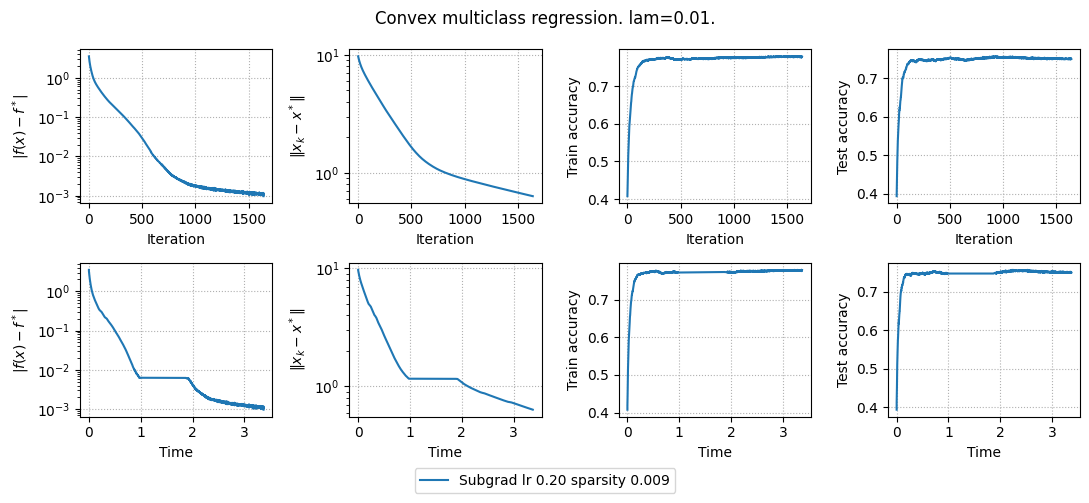

learning rate: 0.2, tolerance: 0.0001
Optimal accuracy 0.7763157486915588
Last diff: 0.0005966424942016602,iter: 10000
train accuracy: 0.7773278951644897, test_accuracy: 0.748630166053772


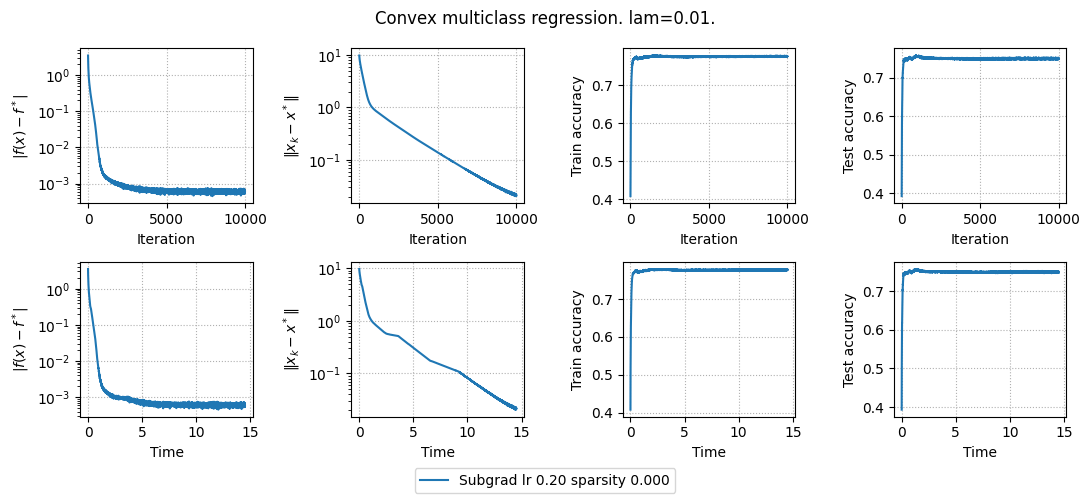

learning rate: 0.2, tolerance: 1e-05
Optimal accuracy 0.7763157486915588
Last diff: 0.0005966424942016602,iter: 10000
train accuracy: 0.7773278951644897, test_accuracy: 0.748630166053772


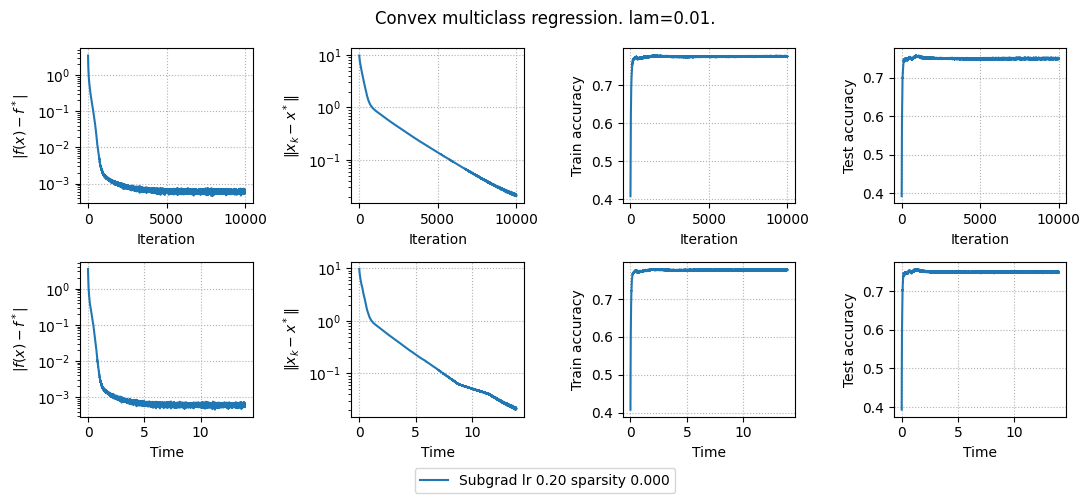

learning rate: 0.25, tolerance: 0.1
Optimal accuracy 0.7763157486915588
Last diff: 0.09980589151382446,iter: 267
train accuracy: 0.7732793092727661, test_accuracy: 0.749315083026886


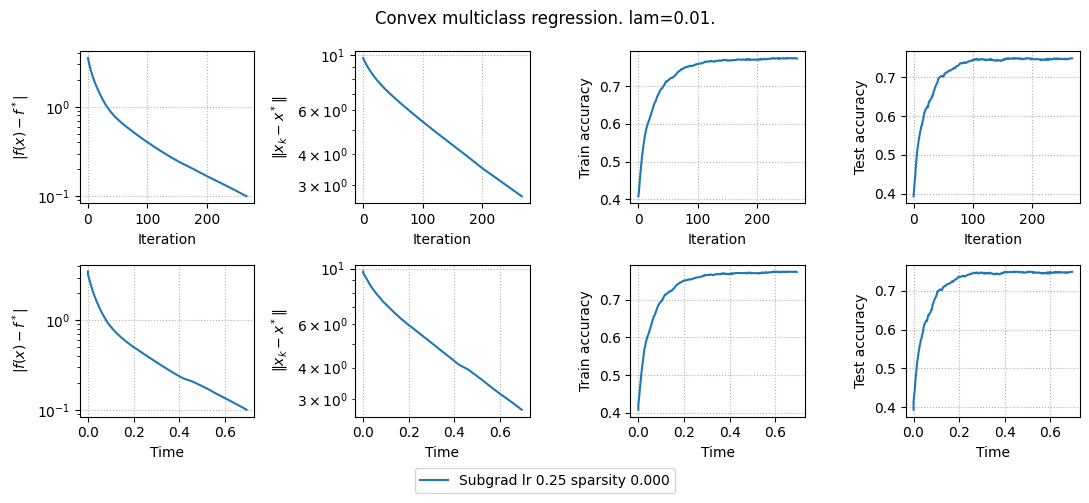

learning rate: 0.25, tolerance: 0.01
Optimal accuracy 0.7763157486915588
Last diff: 0.009904742240905762,iter: 492
train accuracy: 0.7736167311668396, test_accuracy: 0.748630166053772


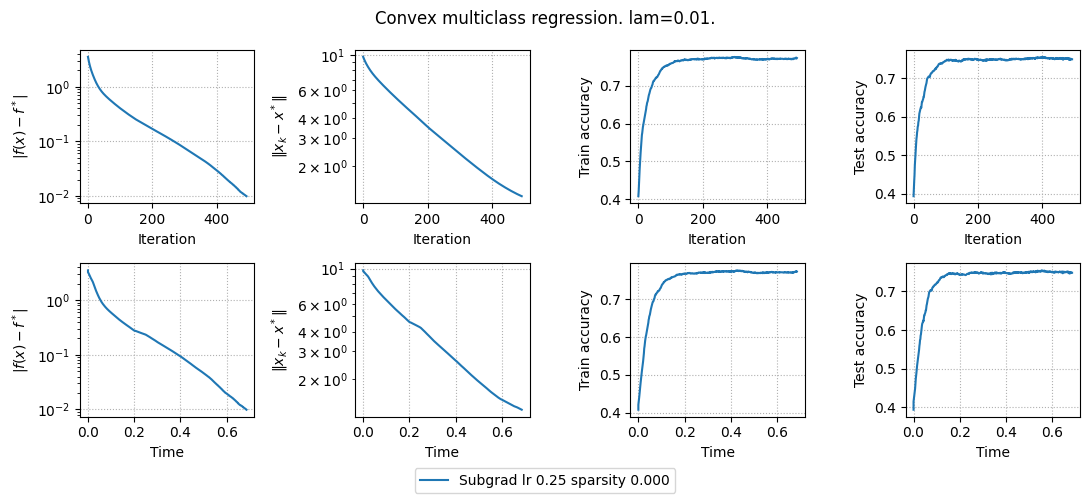

learning rate: 0.25, tolerance: 0.001
Optimal accuracy 0.7763157486915588
Last diff: 0.0009993314743041992,iter: 1548
train accuracy: 0.7776653170585632, test_accuracy: 0.7506849765777588


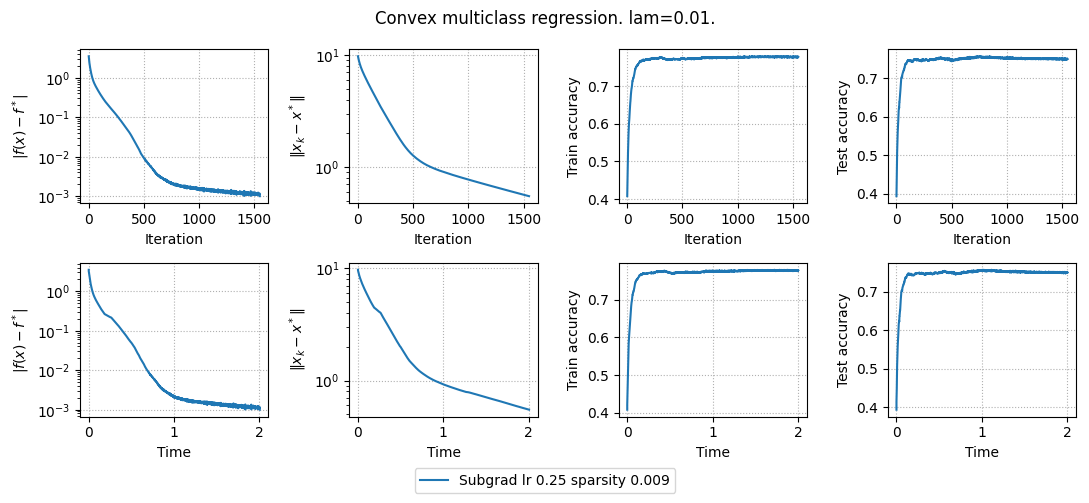

learning rate: 0.25, tolerance: 0.0001
Optimal accuracy 0.7763157486915588
Last diff: 0.0007159113883972168,iter: 10000
train accuracy: 0.7763157486915588, test_accuracy: 0.748630166053772


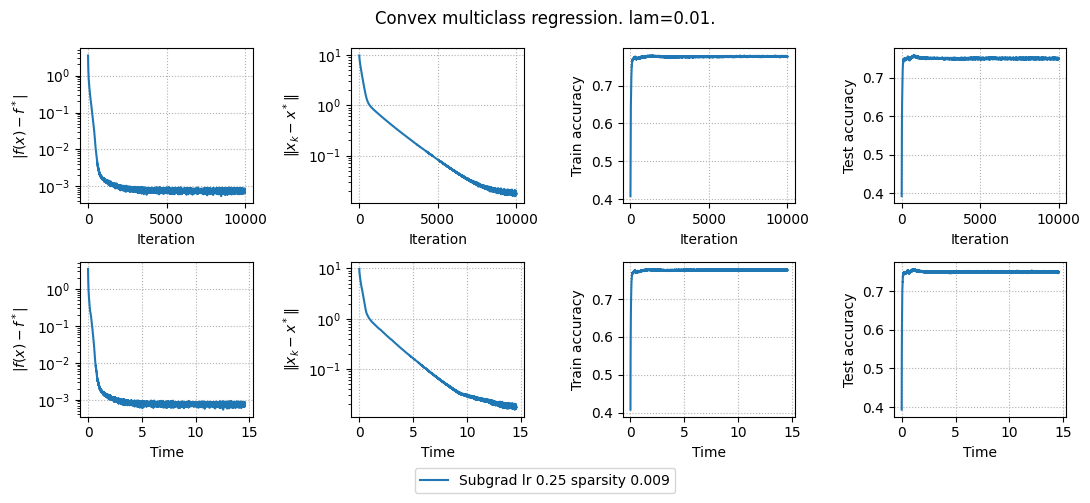

learning rate: 0.25, tolerance: 1e-05
Optimal accuracy 0.7763157486915588
Last diff: 0.0007159113883972168,iter: 10000
train accuracy: 0.7763157486915588, test_accuracy: 0.748630166053772


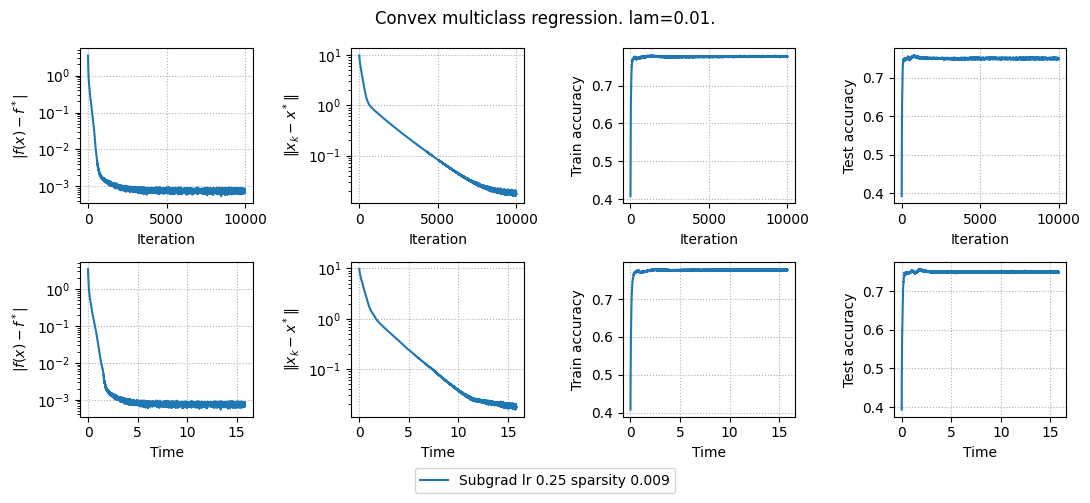

learning rate: 0.5, tolerance: 0.1
Optimal accuracy 0.7763157486915588
Last diff: 0.09973698854446411,iter: 134
train accuracy: 0.7739540934562683, test_accuracy: 0.748630166053772


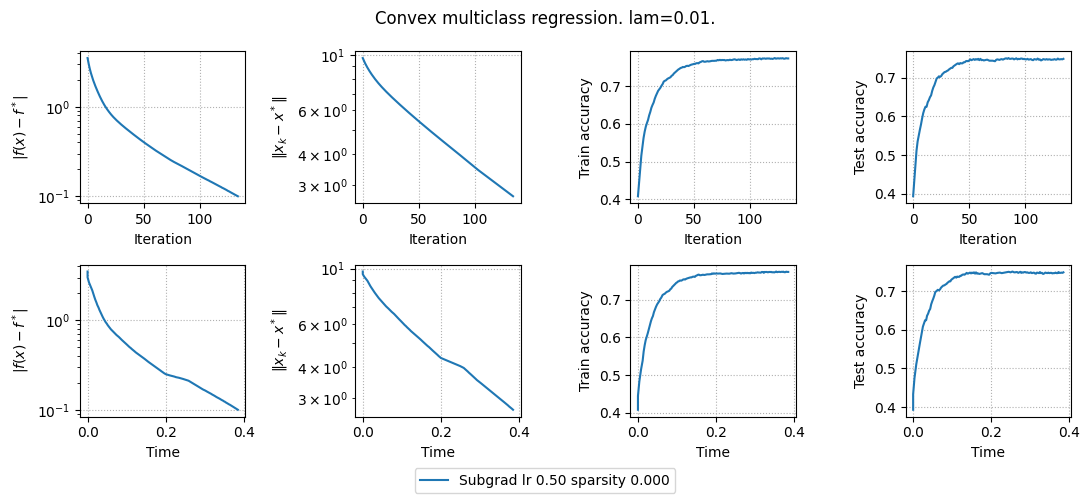

learning rate: 0.5, tolerance: 0.01
Optimal accuracy 0.7763157486915588
Last diff: 0.00996708869934082,iter: 250
train accuracy: 0.7722671627998352, test_accuracy: 0.749315083026886


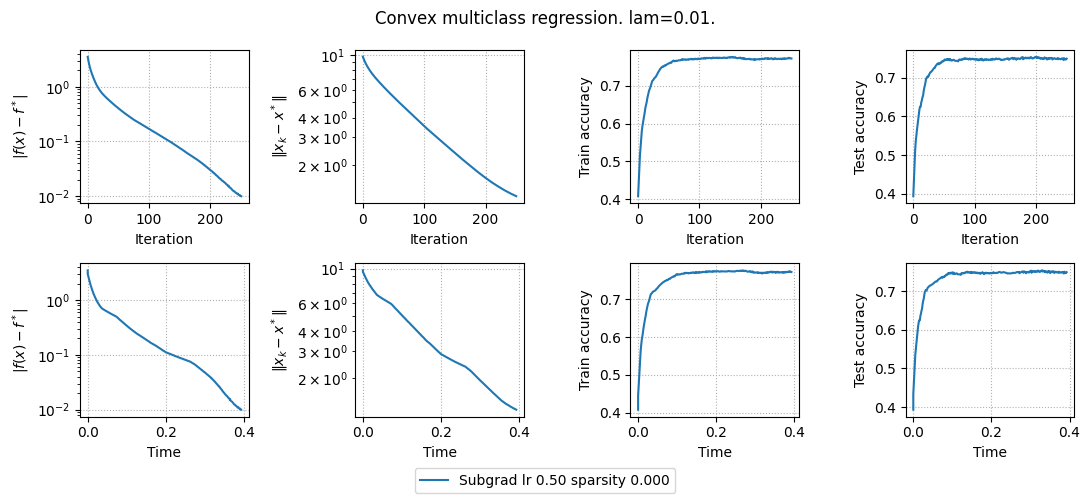

learning rate: 0.5, tolerance: 0.001
Optimal accuracy 0.7763157486915588
Last diff: 0.0015369653701782227,iter: 10000
train accuracy: 0.7759783864021301, test_accuracy: 0.749315083026886


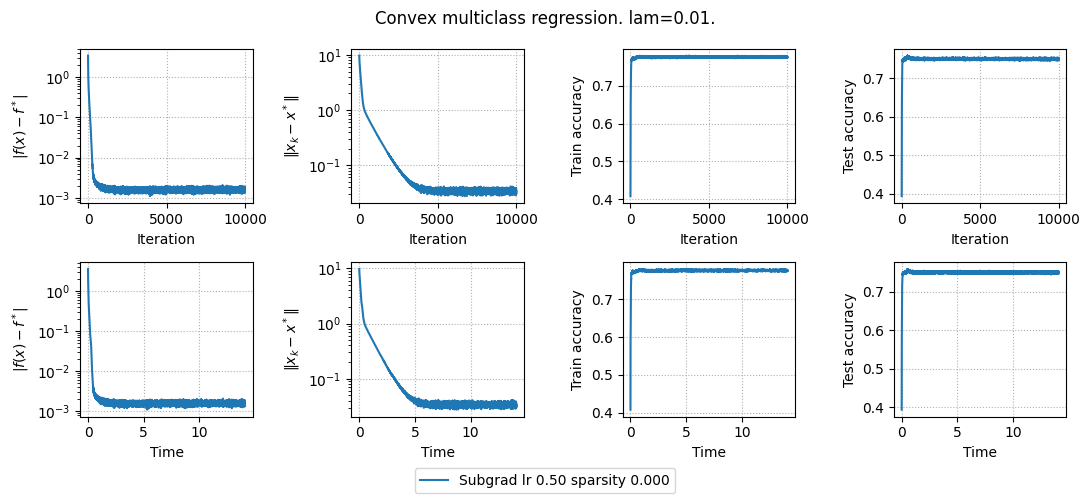

learning rate: 0.5, tolerance: 0.0001
Optimal accuracy 0.7763157486915588
Last diff: 0.0015369653701782227,iter: 10000
train accuracy: 0.7759783864021301, test_accuracy: 0.749315083026886


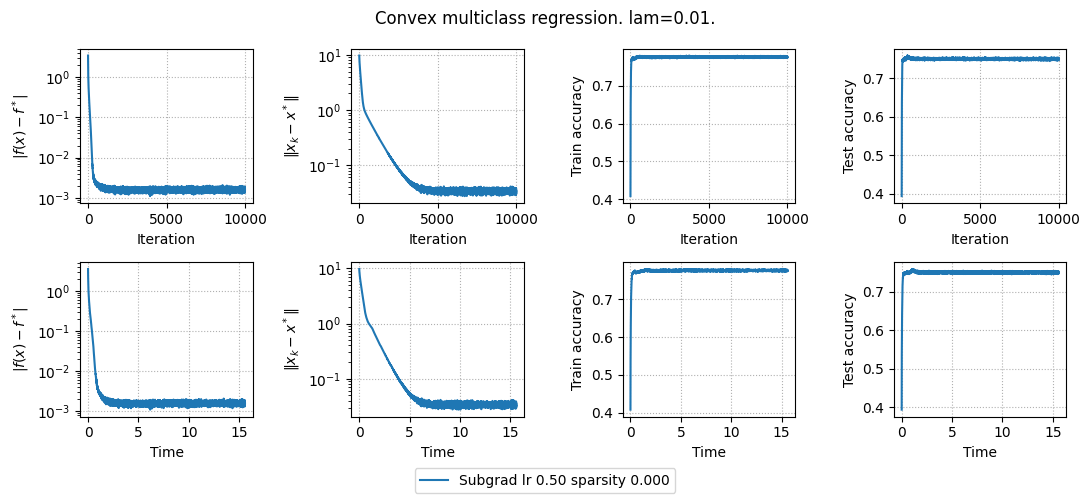

learning rate: 0.5, tolerance: 1e-05
Optimal accuracy 0.7763157486915588
Last diff: 0.0015369653701782227,iter: 10000
train accuracy: 0.7759783864021301, test_accuracy: 0.749315083026886


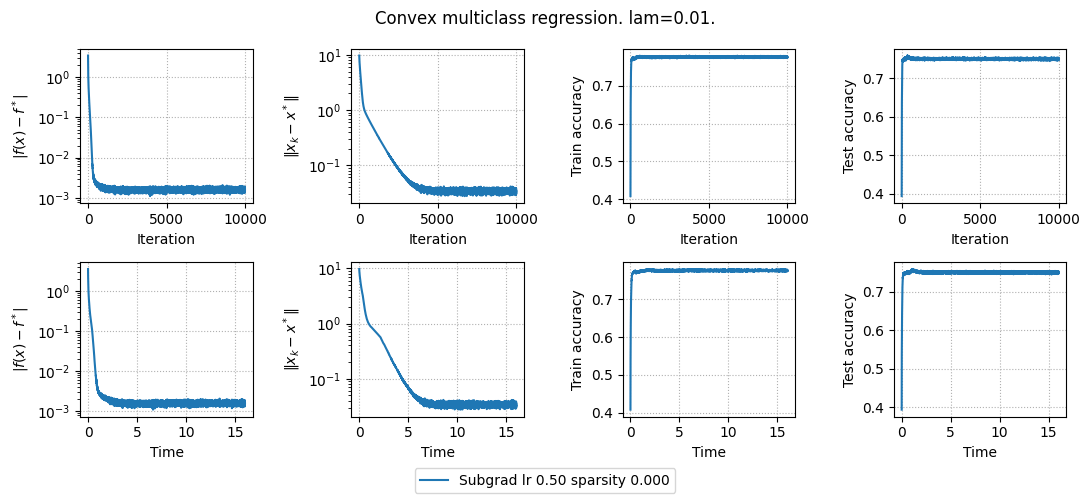

In [4]:
lrs = [1e-2, 1e-1, 0.15, 0.2, 0.25, 0.5]
tols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
lam = 1e-2
for lr, tol in product(lrs, tols):
  params = {
      "lam": lam,
      "tolerance": tol,
      "methods": [
          {
              "lr_method":"const",
              "method": "Subgrad",
              "learning_rate": lr,
              "iterations": 10000,
          },
      ]
  }
  print(f"learning rate: {lr}, tolerance: {tol}")
  results, params = run_experiments(params)
  plot_results(results, params)

learning rate: 0.1, tolerance: 0.01
Optimal accuracy 0.7827260494232178
Last diff: 0.009998917579650879,iter: 6070
train accuracy: 0.780701756477356, test_accuracy: 0.749315083026886


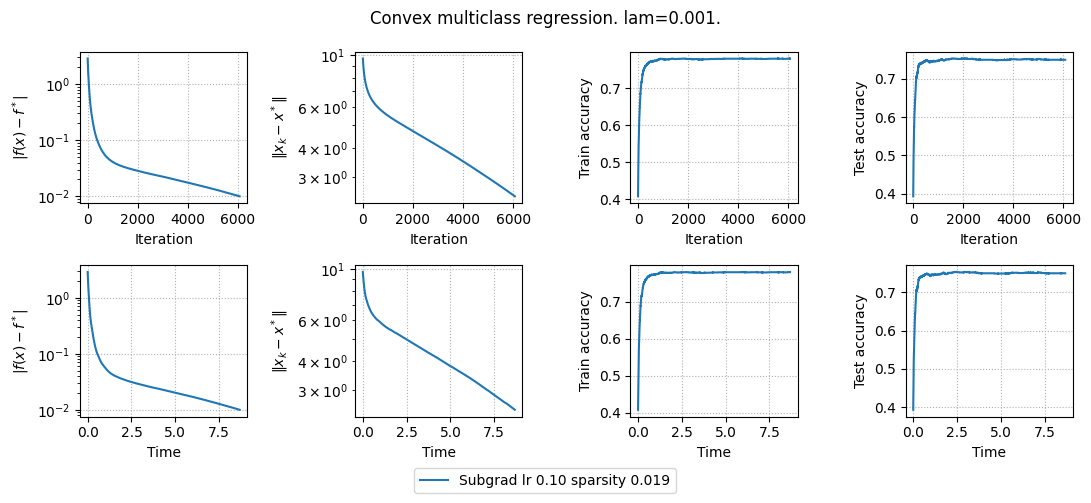

learning rate: 0.15, tolerance: 0.01
Optimal accuracy 0.7827260494232178
Last diff: 0.009998142719268799,iter: 4047
train accuracy: 0.780701756477356, test_accuracy: 0.749315083026886


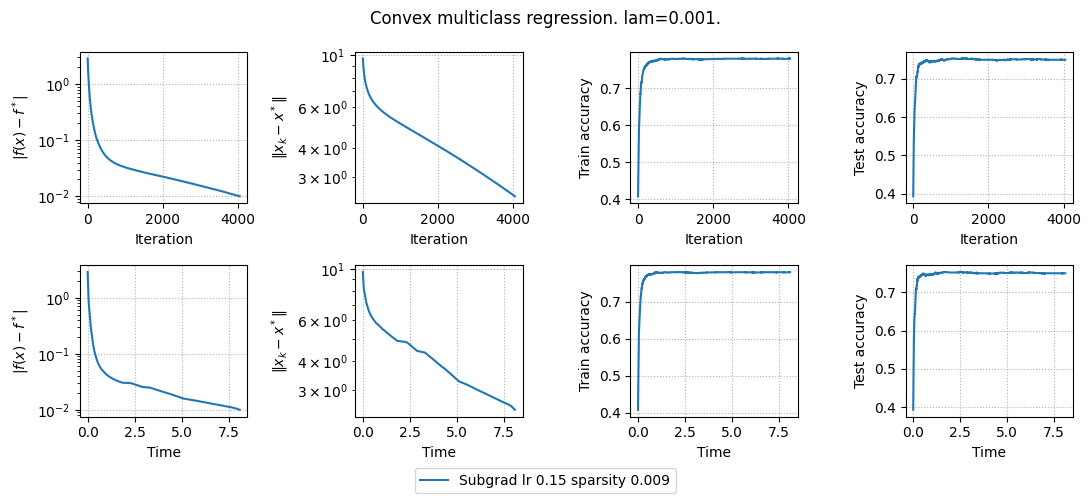

learning rate: 0.2, tolerance: 0.01
Optimal accuracy 0.7827260494232178
Last diff: 0.00999993085861206,iter: 3035
train accuracy: 0.780701756477356, test_accuracy: 0.749315083026886


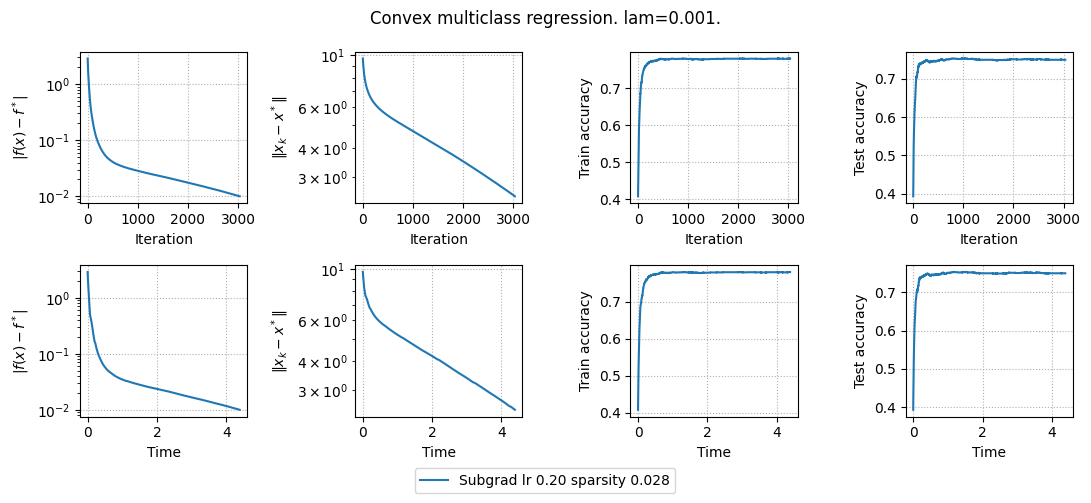

learning rate: 0.25, tolerance: 0.01
Optimal accuracy 0.7827260494232178
Last diff: 0.009993791580200195,iter: 2429
train accuracy: 0.780701756477356, test_accuracy: 0.749315083026886


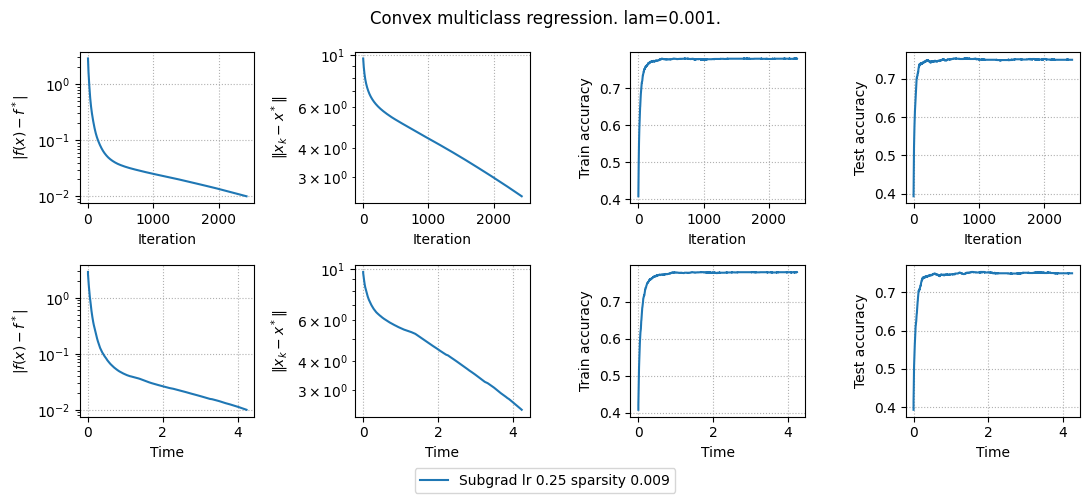

learning rate: 0.5, tolerance: 0.01
Optimal accuracy 0.7827260494232178
Last diff: 0.009989738464355469,iter: 1215
train accuracy: 0.7817139029502869, test_accuracy: 0.749315083026886


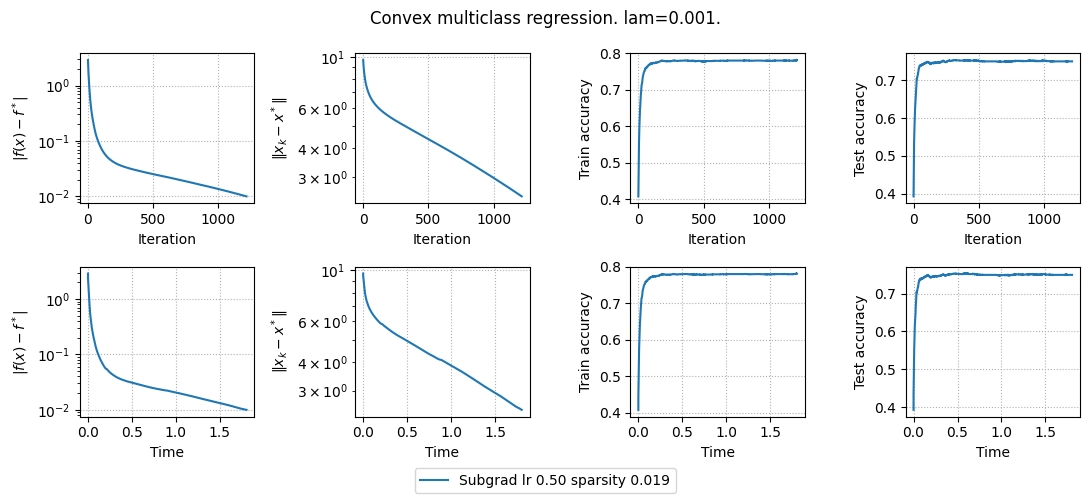

learning rate: 1, tolerance: 0.01
Optimal accuracy 0.7827260494232178
Last diff: 0.00998145341873169,iter: 608
train accuracy: 0.7810391187667847, test_accuracy: 0.749315083026886


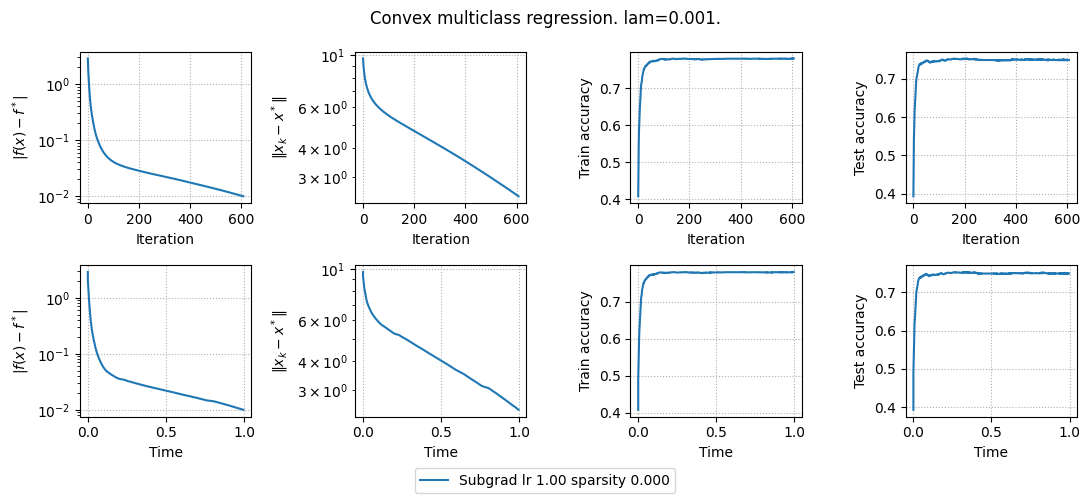

learning rate: 0.1, tolerance: 0.01
Optimal accuracy 0.7371794581413269
Last diff: 0.03918188810348511,iter: 10000
train accuracy: 0.7429149746894836, test_accuracy: 0.7191780805587769


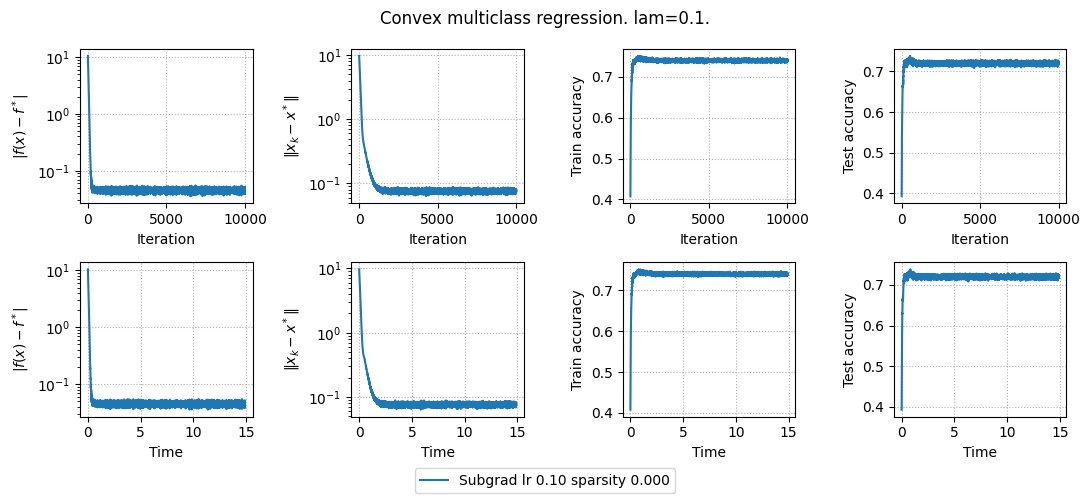

learning rate: 0.15, tolerance: 0.01
Optimal accuracy 0.7371794581413269
Last diff: 0.07060450315475464,iter: 10000
train accuracy: 0.7459514141082764, test_accuracy: 0.716438353061676


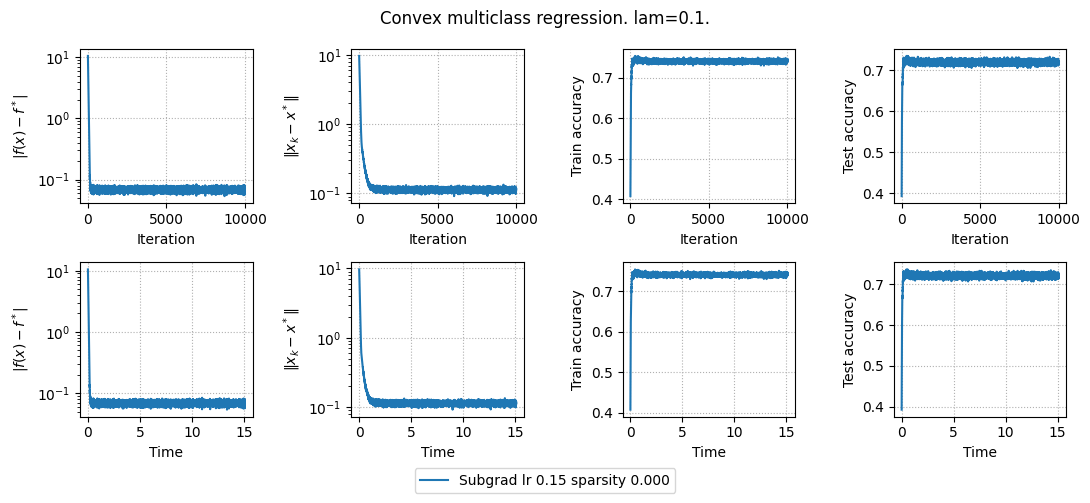

learning rate: 0.2, tolerance: 0.01
Optimal accuracy 0.7371794581413269
Last diff: 0.08404439687728882,iter: 10000
train accuracy: 0.7368420958518982, test_accuracy: 0.7253425121307373


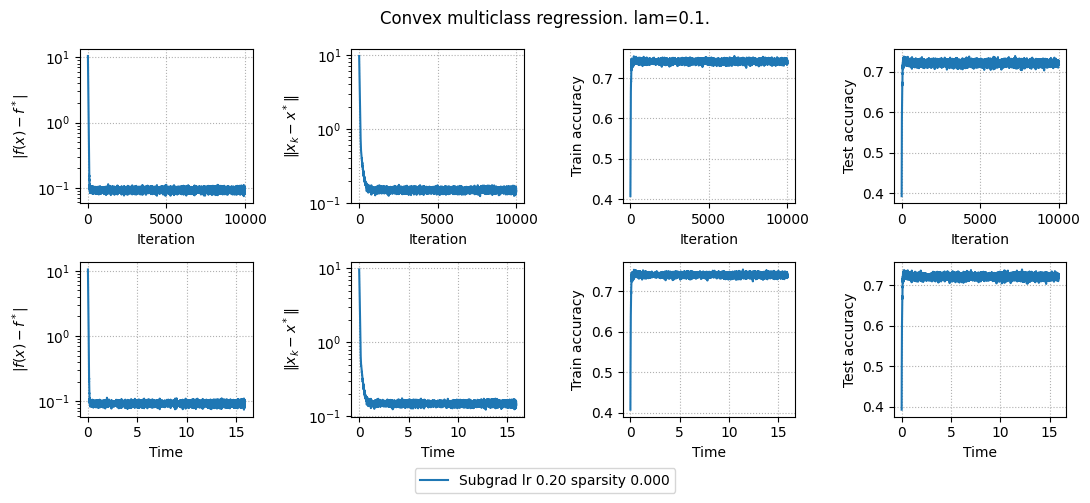

learning rate: 0.25, tolerance: 0.01
Optimal accuracy 0.7371794581413269
Last diff: 0.11824315786361694,iter: 10000
train accuracy: 0.7371794581413269, test_accuracy: 0.7219178080558777


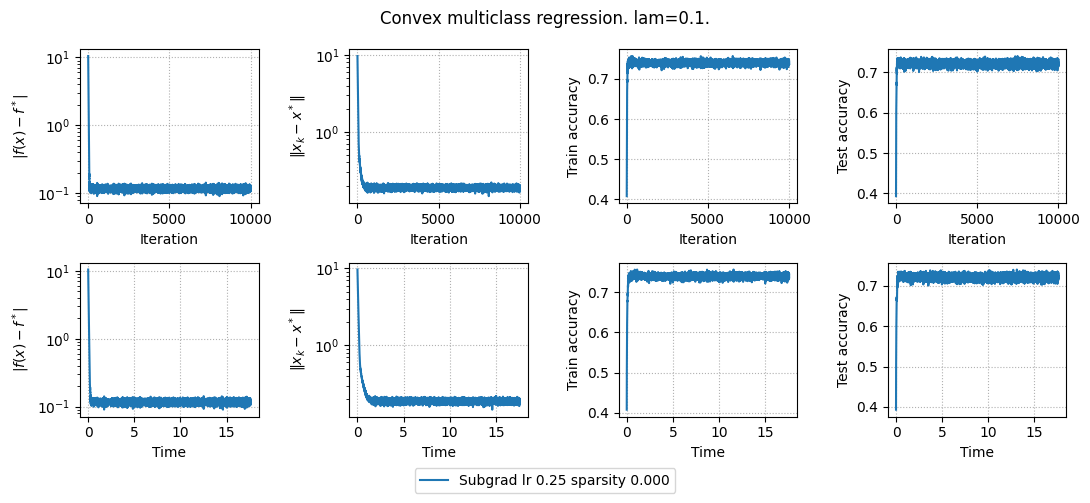

learning rate: 0.5, tolerance: 0.01
Optimal accuracy 0.7371794581413269
Last diff: 0.28061729669570923,iter: 10000
train accuracy: 0.7267206311225891, test_accuracy: 0.699315071105957


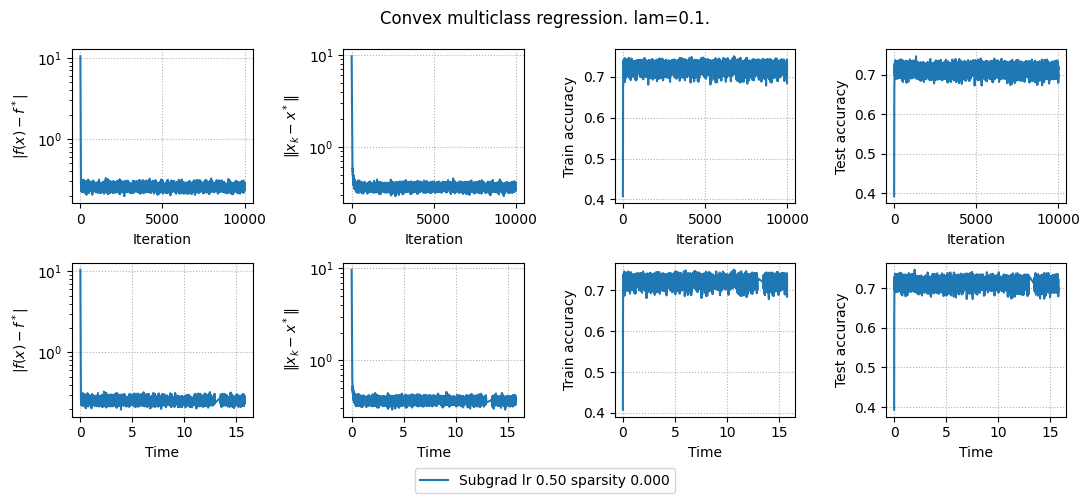

learning rate: 1, tolerance: 0.01
Optimal accuracy 0.7371794581413269
Last diff: 0.7912705540657043,iter: 10000
train accuracy: 0.633940577507019, test_accuracy: 0.6342465877532959


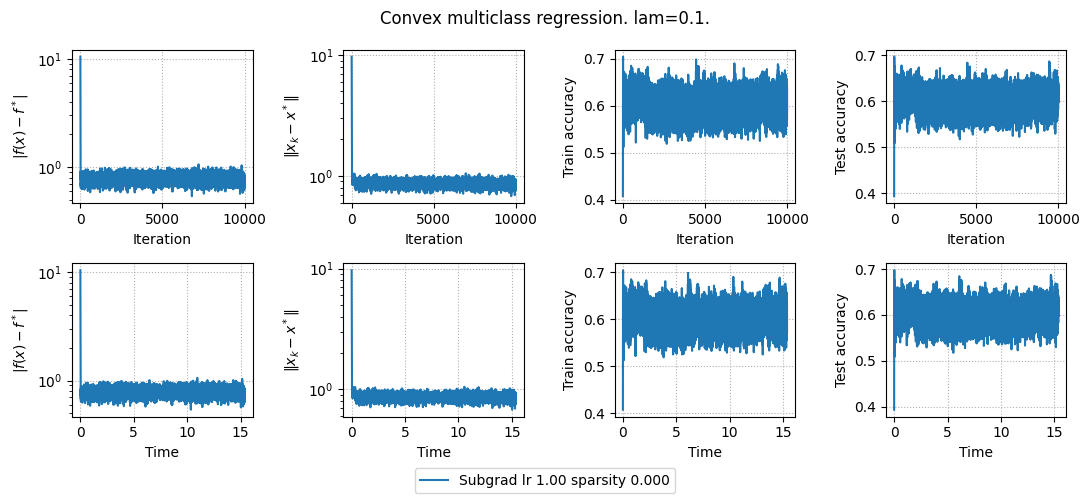

learning rate: 0.1, tolerance: 0.01
Optimal accuracy 0.31545206904411316
Last diff: 5.99053430557251,iter: 10000
train accuracy: 0.37584343552589417, test_accuracy: 0.357534259557724


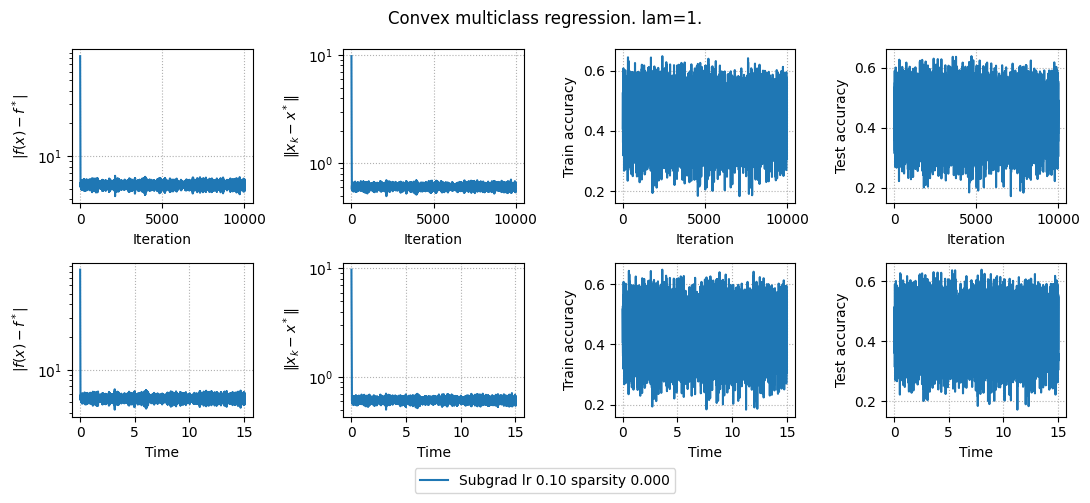

learning rate: 0.15, tolerance: 0.01
Optimal accuracy 0.31545206904411316
Last diff: 7.786226749420166,iter: 10000
train accuracy: 0.2614709734916687, test_accuracy: 0.24452055990695953


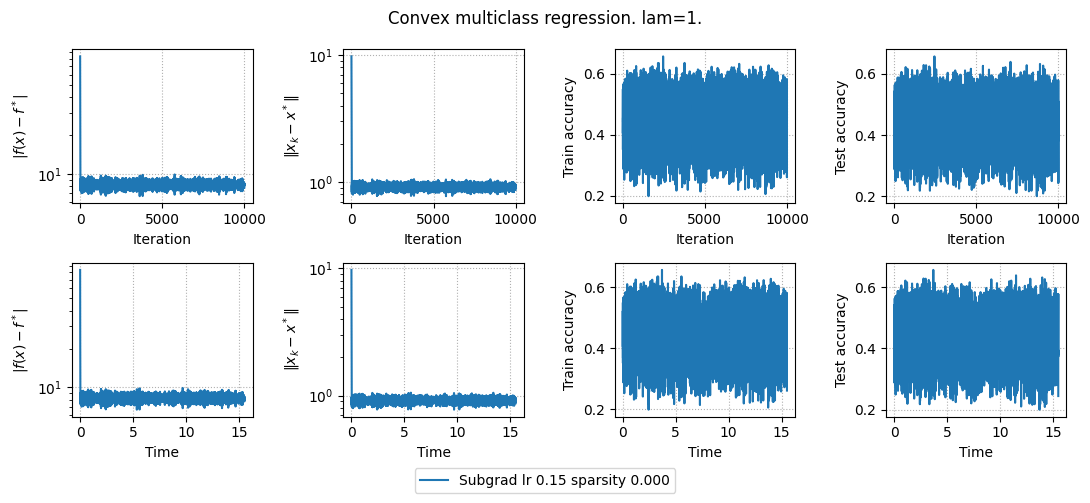

learning rate: 0.2, tolerance: 0.01
Optimal accuracy 0.31545206904411316
Last diff: 10.964920043945312,iter: 10000
train accuracy: 0.38697704672813416, test_accuracy: 0.3821917772293091


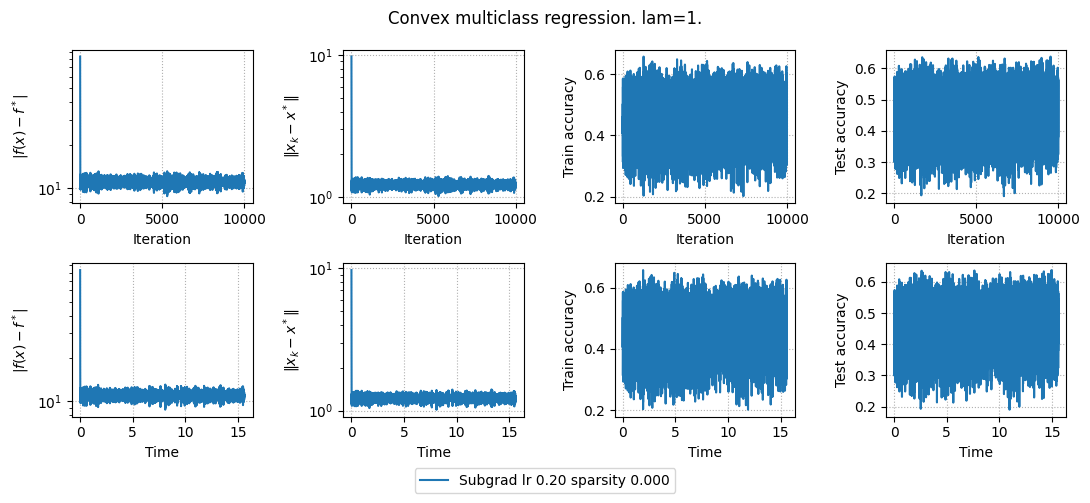

learning rate: 0.25, tolerance: 0.01
Optimal accuracy 0.31545206904411316
Last diff: 12.706384658813477,iter: 10000
train accuracy: 0.2756410241127014, test_accuracy: 0.2678082287311554


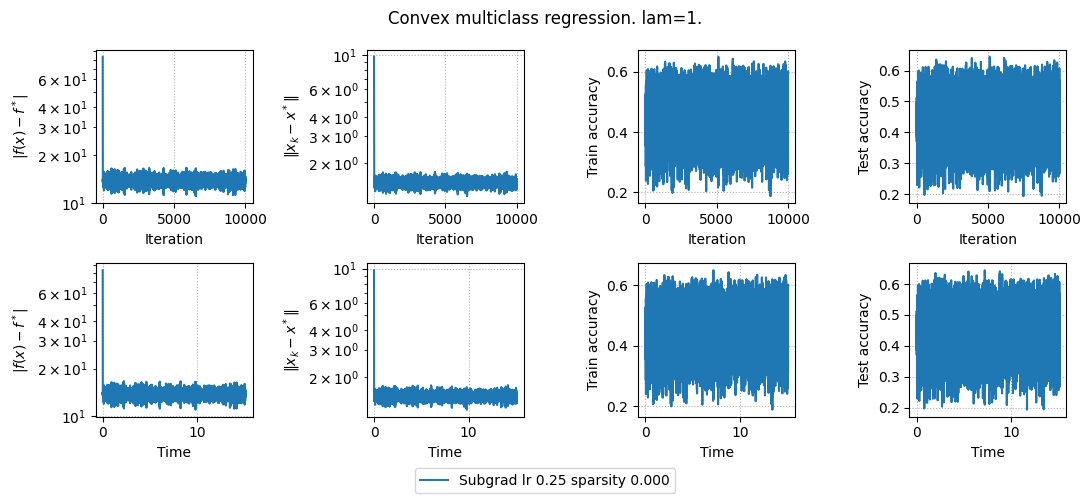

learning rate: 0.5, tolerance: 0.01
Optimal accuracy 0.31545206904411316
Last diff: 26.95601463317871,iter: 10000
train accuracy: 0.44804316759109497, test_accuracy: 0.44178083539009094


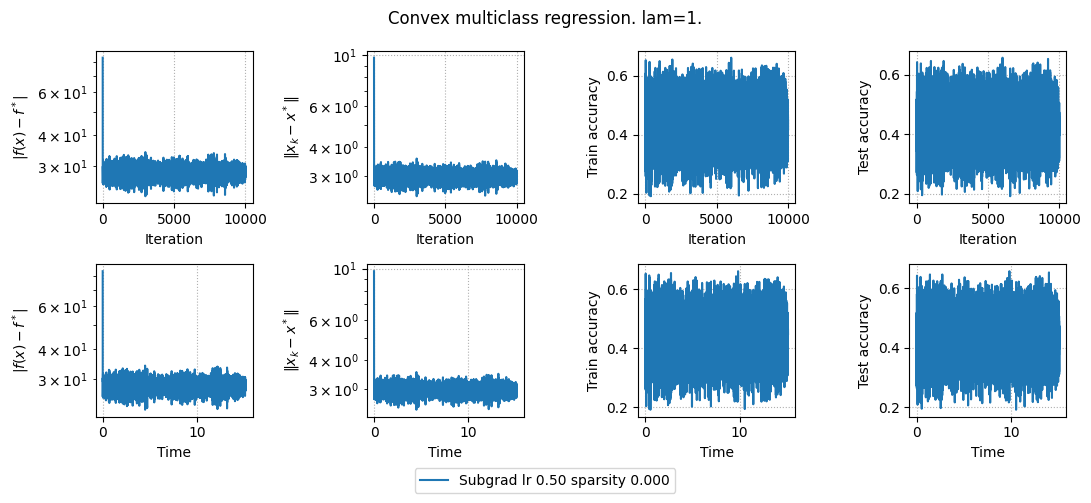

learning rate: 1, tolerance: 0.01
Optimal accuracy 0.31545206904411316
Last diff: 50.3260498046875,iter: 10000
train accuracy: 0.4170040488243103, test_accuracy: 0.4006849527359009


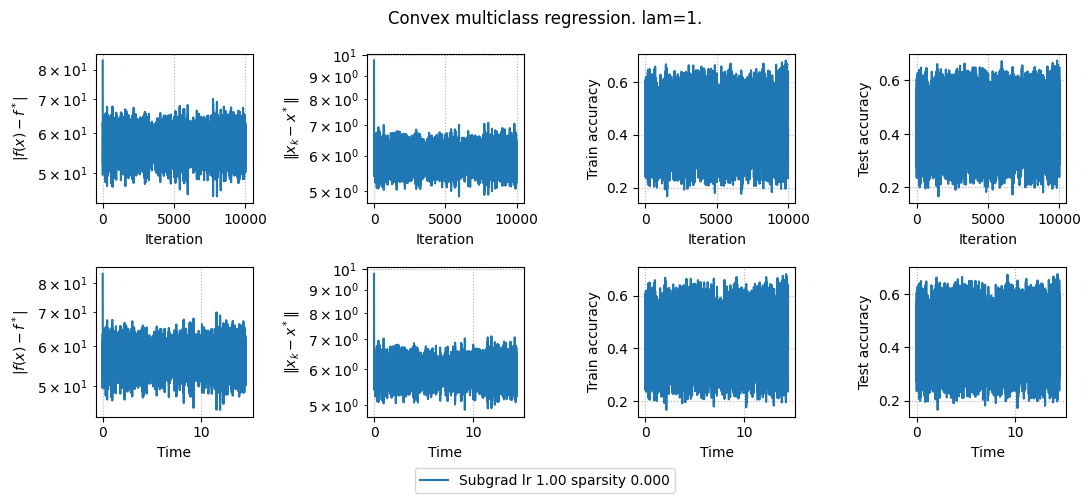

In [6]:
lrs = [1e-1, 0.15, 0.2, 0.25, 0.5, 1]
tol = 1e-2
lams = [1e-3, 1e-1, 1]
for lam, lr in product(lams, lrs):
  params = {
      "lam": lam,
      "tolerance": tol,
      "methods": [
          {
              "lr_method":"const",
              "method": "Subgrad",
              "learning_rate": lr,
              "iterations": 10000,
          },
      ]
  }
  print(f"learning rate: {lr}, tolerance: {tol}")
  results, params = run_experiments(params)
  plot_results(results, params)

#Условия

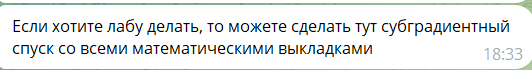

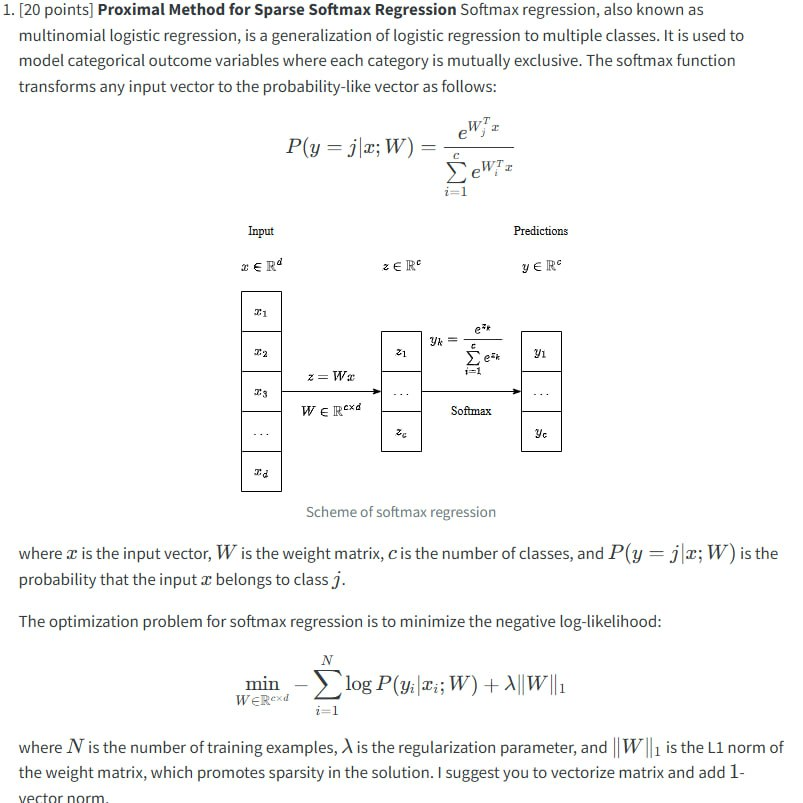

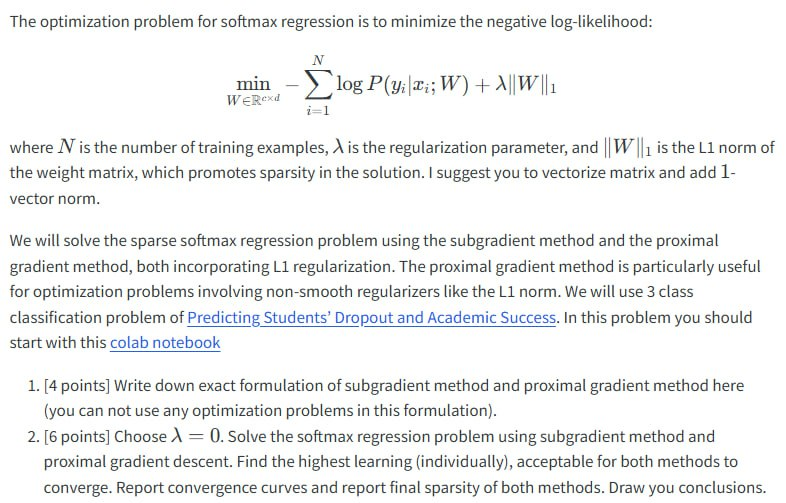

###Замечание по условию
Скорей всего, имелась ввиду ещё и нормализация лосса $\frac{1}{N}$. Все выкладки её не учитывают, но это не более чем константа, так что итоговый спуск выглядит: $$\boxed{W_{k+1} = W_k - \alpha_k \cdot \left(\frac{1}{N} \sum_{i=1}^N  x_i \cdot \left(\begin{pmatrix} \frac{e^{(W_k)_1^T x_i}}{\sum_{j=1}^ce^{(W_k)_j^T x_i}} \\ ... \\ \frac{e^{(W_k)_c^T x_i}}{\sum_{j=1}^ce^{(W_k)_j^T x_i}} \end{pmatrix} - e_{y_i}\right)^T + \lambda \cdot \text{sign}(W_k)\right)}$$
Что и отражено в коде.

#Субградиентный спуск

###Обозначения

Пусть $g(W) := -\sum_{i=1}^{N}\log P(y_i|x_i, W)$, $f(W) := g(W) + \lambda||W||_1$.

###Доказательство внутренности всякой $W_0$

Поймём, что $\forall W_0 \in \mathbb{R}^{c \times d}:W_0 \in Int(\mathbb{R}^{c \times d})$. Ну возьмём просто $W: ||W-W_0||^2 < \varepsilon $. Такие $W \in \mathbb{R}^{c \times d}$, при этом образуют открытый шарик. Доказали.

###Доказательство выпуклости $\lambda||W||_1$

Хотим доказать выпуклость:
$$||\alpha \cdot W_1 + (1-\alpha) W_2||_1 \leq \alpha ||W_1||_1 + (1-\alpha)||W_2||_1$$
$$ \sum_{i,j}|\alpha (W_1)_{ij} + (1-\alpha) (W_2)_{ij}| \leq \sum_{i,j} \alpha |(W_1)_{ij}| + (1-\alpha) |(W_2)_{ij}|$$
Но ведь модуль - выпуклая функция, сумма выпуклых - тоже выпуклая фунция. Получилось то, что хотели. Выпуклость $||W||_1$ доказана. Тогда и $\lambda ||W||_1$ выпукла, т.к. $\lambda$ - скаляр.

###Доказательство выпуклости $g(W)$

Хотим доказать выпуклость:
$$-\sum_{i=1}^{N}\log \frac{e^{(\alpha W_1 + (1-\alpha) W_2)^T_{y_i }x_i}}{\sum_{j=1} ^ {c} e^{(\alpha W_1 + (1-\alpha) W_2)^{T}_{j}x_i}} \leq -\alpha\sum_{i=1}^{N}\log \frac{e^{(W_1)^T_{y_i }x_i}}{\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}} - (1-\alpha)\sum_{i=1}^{N}\log \frac{e^{(W_2)^T_{y_i }x_i}}{\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}}$$
Заметим:
$$-\alpha\sum_{i=1}^{N}\log \frac{e^{(W_1)^T_{y_i }x_i}}{\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}} - (1-\alpha)\sum_{i=1}^{N}\log \frac{e^{(W_2)^T_{y_i }x_i}}{\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}}=-\sum_{i=1}^{N}\log \frac{e^{\alpha(W_1)^T_{y_i }x_i}}{\left(\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}\right)^\alpha} - \sum_{i=1}^{N}\log \frac{e^{(1-\alpha)(W_2)^T_{y_i }x_i}}{\left(\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}\right)^{(1-\alpha)}}$$
В свою очередь, если засунуть всё под одну сумму
$$-\sum_{i=1}^{N}\log \frac{e^{\alpha(W_1)^T_{y_i }x_i}}{\left(\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}\right)^\alpha} - \sum_{i=1}^{N}\log \frac{e^{(1-\alpha)(W_2)^T_{y_i }x_i}}{\left(\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}\right)^{(1-\alpha)}}=-\sum_{i=1}^{N} \log \frac{e^{(\alpha W_1 + (1-\alpha) W_2)^T_{y_i }x_i}}{\left(\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}\right)^\alpha \cdot \left(\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}\right)^{(1-\alpha)}}$$
Заметим теперь, что числители совпадают, так что в неравенстве они поумирают. Итого останется следующее неравенство:
$$\sum_{i=1}^{N} \log \sum_{j=1} ^ {c} e^{(\alpha W_1 + (1-\alpha) W_2)^{T}_{j}x_i} \leq \sum_{i=1}^N\log \left(\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}\right)^\alpha \cdot \left(\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}\right)^{(1-\alpha)}$$
Заметим, что $\log$ - монотонно возрастающая функция. Посмотрим на функции, что под логарифмами:
$$\sum_{j=1} ^ {c} e^{(\alpha W_1 + (1-\alpha) W_2)^{T}_{j}x_i} \leq \left(\sum_{j=1} ^ {c} e^{(W_1)^{T}_{j}x_i}\right)^\alpha \cdot \left(\sum_{j=1} ^ {c} e^{(W_2)^{T}_{j}x_i}\right)^{(1-\alpha)} $$
Заметим, что это Гёльдер с $p=\frac{1}{\alpha}$ и $q = \frac{1}{1-\alpha}$ и исходными функциями вида $e^{(\alpha W_1)^T_j x_i}$ и $e^{((1-\alpha) W_2)^T_j x_i}$. Ну тогда $\log$ неравенству не мешает по вышеописанным причинам, а потом просто сумма. Доказано!

###Подсчёт $\nabla g(W)$

$$Q(W) := -\log \frac{e^{W^T_{y_i }x_i}}{\sum_{j=1} ^ {c} e^{W^{T}_{j}x_i}}=-W_{y_i}^Tx_i+\log{\sum_{j=1} ^ {c} e^{W^{T}_{j}x_i}}$$
$$D(W_{y}^Tx_i)[H] = D(\langle W_{y}, x_i\rangle)[H]=\langle D(W_y)[H], x_i\rangle + \langle W_y,D(x_i)[H]\rangle =\langle H_y, x_i\rangle + 0 \implies \nabla_{W_m}(W^T_yx_i) = x_i \cdot \mathbb{1}\{m=y\}$$
$$z := \sum_{j=1}^c e^{W_j^T x_i}$$
$$D(\log z)[H] = D(\log z)_z\cdot D\left(\sum_{j=1}^c e^{W_j^T x_i}\right)[H] = \frac{1}{z} \cdot \sum_{j=1}^c D(e^{W_j^Tx_i})[H]$$
$$D(e^{W_j^Tx_i})[H]= x_i^T \cdot e^{W_j^T x_i} \cdot H_j$$
$$D(\log z)[H] = \frac{1}{\sum_{j=1}^c e^{W_j^T x_i}} \cdot \sum_{j=1}^c \left( x_i^T \cdot e^{W^t_J x_i} \cdot H_j \right)\implies \nabla_{W_m}(\log z) = \frac{1}{\sum_{j=1}^c e^{W_j^T x_i}} \cdot x_i \cdot e^{W_m^T x_i}$$
Таким образом,
$$\nabla_{W_m} Q = x_i \cdot \left( \frac{ e^{W_m^T x_i}}{\sum_{j=1}^c e^{W_j^T x_i}}-\mathbf{1}\{m=y_i\}\right)$$
Тогда
$$\nabla_{W}Q = x_i \cdot \left(T_i- e_{y_i}\right)^T$$
где $$T_i = \begin{pmatrix} \frac{e^{W_1^T x_i}}{\sum_{j=1}^ce^{W_j^T x_i}} \\ ... \\ \frac{e^{W_c^T x_i}}{\sum_{j=1}^ce^{W_j^T x_i}} \end{pmatrix}$$
Остаётся просуммировать, и получим:
$$\boxed{\nabla g(W) = \sum_{i=1}^N x_i \cdot \left(\begin{pmatrix} \frac{e^{W_1^T x_i}}{\sum_{j=1}^ce^{W_j^T x_i}} \\ ... \\ \frac{e^{W_c^T x_i}}{\sum_{j=1}^ce^{W_j^T x_i}} \end{pmatrix} - e_{y_i}\right)^T}$$

###Подсчёт $h \in \mathcal{D}(\lambda \lVert W \rVert_1)$


Рассмотрим точку $W^0$. Хотим:
$$\sum_{i, j}|W_{ij}| \geq \sum_{i, j}|W^0_{i,j}| + \langle \rho, W - W^0\rangle$$
$$\sum_{i, j}|W_{ij}| - |W^0_{ij}| \geq \sum_{i,j} \rho_{ij} W_{ij} - \sum_{i,j} \rho_{ij} W^0_{ij}$$
Рассмотрим $\rho_{ij} = \text{sign}(W^0_{ij})$
$$\sum_{i, j}|W_{ij}| \geq \sum_{i, j}\text{sign}(W^0_{ij}) \cdot W_{ij}$$
$$\sum_{i,j}|W^0_{ij}|=   \sum_{i, j}\text{sign}(W^0_{ij}) \cdot W^0_{ij}$$
Тогда неравенство доказано. Матрица вида $\text{sign}(W^0)$ подойдёт. Ещё домножим на скаляр $\lambda$  
**Замечание:** это не весь $\mathcal{D}(\lambda \lVert W \rVert_1)$, но для спуска нам нужен один представитель. Если говорить про весь субградиент, то это функция у нас есть сумма выпуклых (модули), тогда по Моро-Рокфеллеру всё есть сумма субградиентов, а субградиент модуля мы знаем.

###Применение свойства субдифференциала

Теперь, по теореме Моро-Рокфеллера: $$\mathcal{D}f(W_0) = \mathcal{D}g(W_0) + \mathcal{D}(\lambda ||W||_1)(W_0)=\nabla g(W_0) + \mathcal{D}(\lambda ||W||_1)(W_0)$$


###Конкретная схема спуска

$$\boxed{W_{k+1} = W_k - \alpha_k \cdot \left(\sum_{i=1}^N x_i \cdot \left(\begin{pmatrix} \frac{e^{(W_k)_1^T x_i}}{\sum_{j=1}^ce^{(W_k)_j^T x_i}} \\ ... \\ \frac{e^{(W_k)_c^T x_i}}{\sum_{j=1}^ce^{(W_k)_j^T x_i}} \end{pmatrix} - e_{y_i}\right)^T + \lambda \cdot \text{sign}(W_k)\right)}$$

#Выводы
| Method | Learning Rate (η) | Tolerance (ε) | # Iterations | Comment | Sparsity | λ | Final Test Accuracy |
|--------|------------------|---------------|--------------|---------|----------|---|---------------------|
| Subgradient Descent | 0.01 |10⁻¹|6655 | | 0.065 | 1e-2 |0.749 |
| Subgradient Descent | 0.15 |10⁻²|814 | | 0.000 | 1e-2 | 0.751 |
| Subgradient Descent | 0.15 |10⁻³|1959 | | 0.000 | 1e-2 | 0.753 |
| Subgradient Descent | 0.01 |10⁻⁴| 10000 | Не сошёлся | 0.074 | 1e-2 | 0.754 |
| Subgradient Descent | 0.01 |10⁻⁵|10000|Не сошёлся| 0.074 | 1e-2 |0.754 |
| Subgradient Descent | 1 |10⁻²|608 | | 0.000 | 1e-3 | 0.749 |
| Subgradient Descent | 0.2 |10⁻²| 10000 | Не сошёлся | 0.000 | 1e-1 |  0.725 |
| Subgradient Descent | 0.5 |10⁻²|10000|Не сошёлся| 0.000 | 1 |0.441 |